# Machine Learning Final Project : Feature Engineering
**Logan Dawes** - CS4783

The goal of this project is to develop a machine learning model for both classification and prediction tasks. The model will be designed to automatically infer missing ingredient lists and nutrient information for a given food item. This enables it to perform ingredient classification as well as nutrient estimation

### Import Libraries

In [333]:
%reset -f

In [ ]:
# Standard data science imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn data processing imports
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

# Other imports
import re
import gc
import json
import warnings
warnings.filterwarnings('ignore')

### Load Dataset
In this step, we are going to first load all 4 datasets and preview thier first 5 rows to confirm that they have been loaded and plan a method of joining the tables into one unified dataset.

In [264]:
# Load datasets
food_data = pd.read_csv('food.csv')
branded_food_data = pd.read_csv('branded_food.csv')
nutrient_data = pd.read_csv('nutrient.csv')
food_nutrient_data = pd.read_csv('food_nutrient.csv')

## Step 1: Exploratory Data Analysis (EDA)

### Initial Data Exploration
First we perform a simple exploration of the features and first rows of each dataset to analyse how we could unify it into a central dataset.

In [265]:
# Display the first few rows of food data
pd.set_option('display.max_columns', None)  
food_data.head()

,fdc_id,data_type,description,food_category_id,publication_date,market_country,trade_channel,microbe_data
0,1105904,branded_food,WESSON Vegetable Oil 1 GAL,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
1,1105905,branded_food,SWANSON BROTH BEEF,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
2,1105906,branded_food,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
3,1105907,branded_food,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
4,1105908,branded_food,SWANSON BROTH CHICKEN,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."


In [266]:
# Display the first few rows of branded food data
branded_food_data.head()

,fdc_id,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients,not_a_significant_source_of,serving_size,serving_size_unit,household_serving_fulltext,branded_food_category,data_source,package_weight,modified_date,available_date,market_country,discontinued_date,preparation_state_code,trade_channel,short_description,material_code
0,1105904,Richardson Oilseed Products (US) Limited,NaN,NaN,27000612323,Vegetable Oil,NaN,15.0,ml,1 Tbsp (15 ml),Oils Edible,GDSN,NaN,2020-10-02,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
1,1105905,CAMPBELL SOUP COMPANY,NaN,NaN,51000198808,"INGREDIENTS: BEEF STOCK, CONTAINS LESS THAN 2%...",NaN,240.0,ml,Amount per serving,Herbs/Spices/Extracts,GDSN,NaN,2020-09-12,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
2,1105906,CAMPBELL SOUP COMPANY,NaN,NaN,51000213273,"INGREDIENTS: CLAM STOCK, POTATOES, CLAMS, CREA...",NaN,440.0,g,PER CONTAINER,Prepared Soups,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
3,1105907,CAMPBELL SOUP COMPANY,NaN,NaN,51000213303,"INGREDIENTS: WATER, CREAM, BROCCOLI, CELERY, V...",NaN,440.0,g,PER CONTAINER,Prepared Soups,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
4,1105908,CAMPBELL SOUP COMPANY,NaN,NaN,51000224637,"INGREDIENTS: CHICKEN STOCK, CONTAINS LESS THAN...",NaN,240.0,ml,Amount per Serving,Herbs/Spices/Extracts,GDSN,NaN,2020-10-03,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN


In [267]:
# Display the first few rows of nutrient data
nutrient_data.head()

,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0
3,1002,Nitrogen,G,202.0,500.0
4,1003,Protein,G,203.0,600.0


In [268]:
# Display the first few rows of food nutrient data
food_nutrient_data.head()

,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,13706927,1105904,1257,0.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN
1,13706930,1105904,1293,53.33,NaN,71.0,NaN,NaN,NaN,NaN,NaN
2,13706926,1105904,1253,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN
3,13706921,1105904,1092,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN
4,13706916,1105904,1008,867.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN


### Joining Datasets
Now that we have seen the basic structure of all the datasets, we can begin looking into how to merge them into a central dataset.

First we can merge food data and branded food data on fdc_id.

In [269]:
# Join Food Datasets
merged_food_data = food_data.merge(branded_food_data, on='fdc_id', how='left')
merged_food_data.head()

,fdc_id,data_type,description,food_category_id,publication_date,market_country_x,trade_channel_x,microbe_data,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients,not_a_significant_source_of,serving_size,serving_size_unit,household_serving_fulltext,branded_food_category,data_source,package_weight,modified_date,available_date,market_country_y,discontinued_date,preparation_state_code,trade_channel_y,short_description,material_code
0,1105904,branded_food,WESSON Vegetable Oil 1 GAL,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...",Richardson Oilseed Products (US) Limited,NaN,NaN,27000612323,Vegetable Oil,NaN,15.0,ml,1 Tbsp (15 ml),Oils Edible,GDSN,NaN,2020-10-02,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
1,1105905,branded_food,SWANSON BROTH BEEF,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...",CAMPBELL SOUP COMPANY,NaN,NaN,51000198808,"INGREDIENTS: BEEF STOCK, CONTAINS LESS THAN 2%...",NaN,240.0,ml,Amount per serving,Herbs/Spices/Extracts,GDSN,NaN,2020-09-12,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
2,1105906,branded_food,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...",CAMPBELL SOUP COMPANY,NaN,NaN,51000213273,"INGREDIENTS: CLAM STOCK, POTATOES, CLAMS, CREA...",NaN,440.0,g,PER CONTAINER,Prepared Soups,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
3,1105907,branded_food,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...",CAMPBELL SOUP COMPANY,NaN,NaN,51000213303,"INGREDIENTS: WATER, CREAM, BROCCOLI, CELERY, V...",NaN,440.0,g,PER CONTAINER,Prepared Soups,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
4,1105908,branded_food,SWANSON BROTH CHICKEN,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...",CAMPBELL SOUP COMPANY,NaN,NaN,51000224637,"INGREDIENTS: CHICKEN STOCK, CONTAINS LESS THAN...",NaN,240.0,ml,Amount per Serving,Herbs/Spices/Extracts,GDSN,NaN,2020-10-03,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN


Next to merge the nutrient data, we'll need to rename id in nutrient_data to nutrient_id to join it with food_nutrient_data.

In [270]:
# Rename id column in nutrient_data to nutrient_id for clarity
nutrient_data.rename(columns={'id': 'nutrient_id'}, inplace=True)

# Join nutrient datasets
merged_nutrient_data = food_nutrient_data.merge(nutrient_data, on='nutrient_id', how='left')
merged_nutrient_data.head()

,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired,name,unit_name,nutrient_nbr,rank
0,13706927,1105904,1257,0.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN,"Fatty acids, total trans",G,605.0,15400.0
1,13706930,1105904,1293,53.33,NaN,71.0,NaN,NaN,NaN,NaN,NaN,"Fatty acids, total polyunsaturated",G,646.0,12900.0
2,13706926,1105904,1253,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN,Cholesterol,MG,601.0,15700.0
3,13706921,1105904,1092,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN,"Potassium, K",MG,306.0,5700.0
4,13706916,1105904,1008,867.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN,Energy,KCAL,208.0,300.0


Before merging the nutrient data into the food dataset, note that each nutrient is currently represented as a separate record for each food item. However, our goal is to have one record per food item, with each nutrient as a separate column.

To accomplish this we will first need to select which features of the nutrient are relevant.

In [271]:
# Nutrient dataset features and datatype
merged_nutrient_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25652681 entries, 0 to 25652680
Data columns (total 15 columns):
 #   Column             Dtype  
---  ------             -----  
 0   id                 int64  
 1   fdc_id             int64  
 2   nutrient_id        int64  
 3   amount             float64
 4   data_points        float64
 5   derivation_id      float64
 6   min                float64
 7   max                float64
 8   median             float64
 9   footnote           float64
 10  min_year_acquired  float64
 11  name               object 
 12  unit_name          object 
 13  nutrient_nbr       float64
 14  rank               float64
dtypes: float64(10), int64(3), object(2)
memory usage: 2.9+ GB


In [272]:
# Nutrient dataset null values
merged_nutrient_data.isnull().sum()

id                          0
fdc_id                      0
nutrient_id                 0
amount                      0
data_points          25652681
derivation_id             830
min                  25652681
max                  25652681
median               25652681
footnote             25652681
min_year_acquired    25652681
name                        0
unit_name                   0
nutrient_nbr                0
rank                     4710
dtype: int64

From this brief analysis we can gather that the most relevant features will be fdc_id, name, unit_name, and amount.

- fdc_id will be used to join the nutrient to its corresponding food item.

- name will be the name of the feature (nutrient name).

- amount and unit_name will be the value of the feature (how much of that nutrient).


In [273]:
# Pivot nutrients so each nutrient becomes two columns: amount and unit_name
nutrient_amount_pivot = merged_nutrient_data.pivot_table(
    index='fdc_id',
    columns='name',
    values='amount'
 )
nutrient_unit_pivot = merged_nutrient_data.pivot_table(
    index='fdc_id',
    columns='name',
    values='unit_name',
    aggfunc='first'
 )

# Rename columns to include suffixes for clarity
nutrient_amount_pivot.columns = [f'{col} amount' for col in nutrient_amount_pivot.columns]
nutrient_unit_pivot.columns = [f'{col} unit' for col in nutrient_unit_pivot.columns]

# Concatenate amount and unit pivots
nutrient_full_pivot = pd.concat([nutrient_amount_pivot, nutrient_unit_pivot], axis=1)

# Join both datasets using the full pivot
final_food_data = merged_food_data.merge(nutrient_full_pivot, on='fdc_id', how='left')

# Memory cleanup after merging
def memory_cleanup(data):
    for var in data:
        if var in locals():
            del globals()[var]
    gc.collect()

memory_cleanup(['food_data', 'food_nutrient_data', 'branded_food_data', 'nutrient_data', 'merged_nutrient_data', 'merged_food_data', 'nutrient_amount_pivot', 'nutrient_unit_pivot', 'nutrient_full_pivot'])

%reset_selective -f food_data food_nutrient_data branded_food_data nutrient_data merged_nutrient_data merged_food_data nutrient_amount_pivot nutrient_unit_pivot nutrient_full_pivot

# Display the final food data
final_food_data.head()

,fdc_id,data_type,description,food_category_id,publication_date,market_country_x,trade_channel_x,microbe_data,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients,not_a_significant_source_of,serving_size,serving_size_unit,household_serving_fulltext,branded_food_category,data_source,package_weight,modified_date,available_date,market_country_y,discontinued_date,preparation_state_code,trade_channel_y,short_description,material_code,Acetic acid amount,Alanine amount,"Alcohol, ethyl amount",Arginine amount,Ash amount,Aspartic acid amount,Beta-glucans amount,Biotin amount,Caffeine amount,"Calcium, Ca amount","Carbohydrate, by difference amount","Carbohydrate, other amount","Carotene, beta amount","Chlorine, Cl amount",Cholesterol amount,"Choline, from phosphotidyl choline amount","Choline, total amount","Chromium, Cr amount","Copper, Cu amount",Cysteine amount,Cystine amount,Energy amount,Epigallocatechin-3-gallate amount,"Fatty acids, total monounsaturated amount","Fatty acids, total polyunsaturated amount","Fatty acids, total saturated amount","Fatty acids, total trans amount","Fiber, insoluble amount","Fiber, soluble amount","Fiber, total dietary amount","Fluoride, F amount","Folate, DFE amount","Folate, food amount","Folate, total amount",Folic acid amount,Fructose amount,Glucose amount,Glutamic acid amount,Glutamine amount,Glycine amount,Histidine amount,Inositol amount,Inulin amount,"Iodine, I amount","Iron, Fe amount",Isoleucine amount,Lactic acid amount,Lactose amount,Leucine amount,Lignin amount,Lutein + zeaxanthin amount,Lysine amount,"Magnesium, Mg amount","Manganese, Mn amount",Methionine amount,"Molybdenum, Mo amount",Niacin amount,PUFA 18:2 amount,"PUFA 18:2 n-6 c,c amount","PUFA 18:3 n-3 c,c,c (ALA) amount",Pantothenic acid amount,Phenylalanine amount,"Phosphorus, P amount","Potassium, K amount",Proline amount,Protein amount,Retinol amount,Riboflavin amount,Ribose amount,SFA 10:0 amount,SFA 12:0 amount,SFA 22:0 amount,SFA 8:0 amount,"Salt, NaCl amount","Selenium, Se amount",Serine amount,"Sodium, Na amount",Sorbitol amount,Starch amount,"Sugars, Total amount","Sugars, added amount","Sugars, intrinsic amount",Taurine amount,Thiamin amount,Threonine amount,Total Sugars amount,Total lipid (fat) amount,Total sugar alcohols amount,Tryptophan amount,Tyrosine amount,Valine amount,Vitamin A amount,"Vitamin A, IU amount","Vitamin A, RAE amount",Vitamin B-12 amount,Vitamin B-6 amount,"Vitamin C, total ascorbic acid amount",Vitamin D (D2 + D3) amount,"Vitamin D (D2 + D3), International Units amount",Vitamin D2 (ergocalciferol) amount,Vitamin D3 (cholecalciferol) amount,Vitamin E amount,Vitamin E (alpha-tocopherol) amount,Vitamin E (label entry primarily) amount,Vitamin K (phylloquinone) amount,Water amount,Xylitol amount,"Zinc, Zn amount",Acetic acid unit,Alanine unit,"Alcohol, ethyl unit",Arginine unit,Ash unit,Aspartic acid unit,Beta-glucans unit,Biotin unit,Caffeine unit,"Calcium, Ca unit","Carbohydrate, by difference unit","Carbohydrate, other unit","Carotene, beta unit","Chlorine, Cl unit",Cholesterol unit,"Choline, from phosphotidyl choline unit","Choline, total unit","Chromium, Cr unit","Copper, Cu unit",Cysteine unit,Cystine unit,Energy unit,Epigallocatechin-3-gallate unit,"Fatty acids, total monounsaturated unit","Fatty acids, total polyunsaturated unit","Fatty acids, total saturated unit","Fatty acids, total trans unit","Fiber, insoluble unit","Fiber, soluble unit","Fiber, total dietary unit","Fluoride, F unit","Folate, DFE unit","Folate, food unit","Folate, total unit",Folic acid unit,Fructose unit,Glucose unit,Glutamic acid unit,Glutamine unit,Glycine unit,Histidine unit,Inositol unit,Inulin unit,"Iodine, I unit","Iron, Fe unit",Isoleucine unit,Lactic acid unit,Lactose unit,Leucine unit,Lignin unit,Lutein + zeaxanthin unit,Lysine unit,"Magnesium, Mg unit","Manganese, Mn unit",Methionine unit,"Molybdenum, Mo unit",Niacin unit,PUFA 18:2 unit,"PUFA 18:2 n-6 c,c unit","PUFA 18:3 n-3 c,c,c (ALA) unit",Pantothenic aci

### Full Data Exploration
After merging the datasets, we can explore this unified dataset in its entirety to plan the handling of missing values, remove features irrelevant to our model, and more.

In [274]:
# Dataset Shape
print("Dataset Shape: ", final_food_data.shape)

# Display all columns and their datatypes
def display_column_types(df):
    for i, col in enumerate(df.columns, 1):
        print(f"{i}. {col} - {df[col].dtype}")

display_column_types(final_food_data)

Dataset Shape:  (1977398, 244)
1. fdc_id - int64
2. data_type - object
3. description - object
4. food_category_id - float64
5. publication_date - object
6. market_country_x - object
7. trade_channel_x - object
8. microbe_data - object
9. brand_owner - object
10. brand_name - object
11. subbrand_name - object
12. gtin_upc - object
13. ingredients - object
14. not_a_significant_source_of - object
15. serving_size - float64
16. serving_size_unit - object
17. household_serving_fulltext - object
18. branded_food_category - object
19. data_source - object
20. package_weight - object
21. modified_date - object
22. available_date - object
23. market_country_y - object
24. discontinued_date - object
25. preparation_state_code - object
26. trade_channel_y - object
27. short_description - object
28. material_code - float64
29. Acetic acid amount - float64
30. Alanine amount - float64
31. Alcohol, ethyl amount - float64
32. Arginine amount - float64
33. Ash amount - float64
34. Aspartic acid amou

#### Size Reduction
We will perform a quick step to reduce the size of the dataset for memory and compuational efficiency.

In [275]:
# Reduce datatype sizes for memory efficiency
def reduce_memory_usage(df):
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
        gc.collect()
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
        gc.collect()
    # Convert suitable object columns to category
    for col in df.select_dtypes(include=['object']).columns:
        if df[col].apply(lambda x: isinstance(x, list)).any():
            continue
        num_unique = df[col].nunique()
        # Convert to category if unique values are low
        if num_unique < 1000:
            df[col] = df[col].astype('category')
            gc.collect()
    return df

In [276]:
final_food_data = reduce_memory_usage(final_food_data)
display_column_types(final_food_data)

1. fdc_id - int32
2. data_type - category
3. description - object
4. food_category_id - float32
5. publication_date - category
6. market_country_x - category
7. trade_channel_x - category
8. microbe_data - category
9. brand_owner - object
10. brand_name - object
11. subbrand_name - object
12. gtin_upc - object
13. ingredients - object
14. not_a_significant_source_of - object
15. serving_size - float32
16. serving_size_unit - category
17. household_serving_fulltext - object
18. branded_food_category - category
19. data_source - category
20. package_weight - object
21. modified_date - object
22. available_date - category
23. market_country_y - category
24. discontinued_date - category
25. preparation_state_code - category
26. trade_channel_y - category
27. short_description - object
28. material_code - float64
29. Acetic acid amount - float32
30. Alanine amount - float32
31. Alcohol, ethyl amount - float32
32. Arginine amount - float32
33. Ash amount - float32
34. Aspartic acid amount - 

In [277]:
# Display Dataset Statistics
final_food_data.describe(include='all')

,fdc_id,data_type,description,food_category_id,publication_date,market_country_x,trade_channel_x,microbe_data,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients,not_a_significant_source_of,serving_size,serving_size_unit,household_serving_fulltext,branded_food_category,data_source,package_weight,modified_date,available_date,market_country_y,discontinued_date,preparation_state_code,trade_channel_y,short_description,material_code,Acetic acid amount,Alanine amount,"Alcohol, ethyl amount",Arginine amount,Ash amount,Aspartic acid amount,Beta-glucans amount,Biotin amount,Caffeine amount,"Calcium, Ca amount","Carbohydrate, by difference amount","Carbohydrate, other amount","Carotene, beta amount","Chlorine, Cl amount",Cholesterol amount,"Choline, from phosphotidyl choline amount","Choline, total amount","Chromium, Cr amount","Copper, Cu amount",Cysteine amount,Cystine amount,Energy amount,Epigallocatechin-3-gallate amount,"Fatty acids, total monounsaturated amount","Fatty acids, total polyunsaturated amount","Fatty acids, total saturated amount","Fatty acids, total trans amount","Fiber, insoluble amount","Fiber, soluble amount","Fiber, total dietary amount","Fluoride, F amount","Folate, DFE amount","Folate, food amount","Folate, total amount",Folic acid amount,Fructose amount,Glucose amount,Glutamic acid amount,Glutamine amount,Glycine amount,Histidine amount,Inositol amount,Inulin amount,"Iodine, I amount","Iron, Fe amount",Isoleucine amount,Lactic acid amount,Lactose amount,Leucine amount,Lignin amount,Lutein + zeaxanthin amount,Lysine amount,"Magnesium, Mg amount","Manganese, Mn amount",Methionine amount,"Molybdenum, Mo amount",Niacin amount,PUFA 18:2 amount,"PUFA 18:2 n-6 c,c amount","PUFA 18:3 n-3 c,c,c (ALA) amount",Pantothenic acid amount,Phenylalanine amount,"Phosphorus, P amount","Potassium, K amount",Proline amount,Protein amount,Retinol amount,Riboflavin amount,Ribose amount,SFA 10:0 amount,SFA 12:0 amount,SFA 22:0 amount,SFA 8:0 amount,"Salt, NaCl amount","Selenium, Se amount",Serine amount,"Sodium, Na amount",Sorbitol amount,Starch amount,"Sugars, Total amount","Sugars, added amount","Sugars, intrinsic amount",Taurine amount,Thiamin amount,Threonine amount,Total Sugars amount,Total lipid (fat) amount,Total sugar alcohols amount,Tryptophan amount,Tyrosine amount,Valine amount,Vitamin A amount,"Vitamin A, IU amount","Vitamin A, RAE amount",Vitamin B-12 amount,Vitamin B-6 amount,"Vitamin C, total ascorbic acid amount",Vitamin D (D2 + D3) amount,"Vitamin D (D2 + D3), International Units amount",Vitamin D2 (ergocalciferol) amount,Vitamin D3 (cholecalciferol) amount,Vitamin E amount,Vitamin E (alpha-tocopherol) amount,Vitamin E (label entry primarily) amount,Vitamin K (phylloquinone) amount,Water amount,Xylitol amount,"Zinc, Zn amount",Acetic acid unit,Alanine unit,"Alcohol, ethyl unit",Arginine unit,Ash unit,Aspartic acid unit,Beta-glucans unit,Biotin unit,Caffeine unit,"Calcium, Ca unit","Carbohydrate, by difference unit","Carbohydrate, other unit","Carotene, beta unit","Chlorine, Cl unit",Cholesterol unit,"Choline, from phosphotidyl choline unit","Choline, total unit","Chromium, Cr unit","Copper, Cu unit",Cysteine unit,Cystine unit,Energy unit,Epigallocatechin-3-gallate unit,"Fatty acids, total monounsaturated unit","Fatty acids, total polyunsaturated unit","Fatty acids, total saturated unit","Fatty acids, total trans unit","Fiber, insoluble unit","Fiber, soluble unit","Fiber, total dietary unit","Fluoride, F unit","Folate, DFE unit","Folate, food unit","Folate, total unit",Folic acid unit,Fructose unit,Glucose unit,Glutamic acid unit,Glutamine unit,Glycine unit,Histidine unit,Inositol unit,Inulin unit,"Iodine, I unit","Iron, Fe unit",Isoleucine unit,Lactic acid unit,Lactose unit,Leucine unit,Lignin unit,Lutein + zeaxanthin unit,Lysine unit,"Magnesium, Mg unit","Manganese, Mn unit",Methionine unit,"Molybdenum, Mo unit",Niacin unit,PUFA 18:2 unit,"PUFA 18:2 n-6 c,c unit","PUFA 18:3 n-3 c,c,c (ALA) unit",Pantothenic aci

### Missing Values
Now that we have seen some basic statistics on our dataset, we can start data preprocessing methods. The first being missing values. We will create a dataframe and visualization to guide an imputation strategy.

In [278]:
# Display missing values dataframe
def display_missing_values(df):
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    missing_df = pd.DataFrame({
        'Column': missing_data.index,
        'Missing_Count': missing_data.values,
        'Missing_Percentage': missing_percent.values,
        'Datatype': df.dtypes.values
    })
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        print(missing_df)

display_missing_values(final_food_data)

                                              Column  Missing_Count  \
3                                   food_category_id        1977398   
34                               Beta-glucans amount        1977397   
109                         Sugars, intrinsic amount        1977397   
217                           Sugars, intrinsic unit        1977397   
142                                Beta-glucans unit        1977397   
99                                   SFA 22:0 amount        1977396   
207                                    SFA 22:0 unit        1977396   
204                                      Ribose unit        1977395   
96                                     Ribose amount        1977395   
77                                     Lignin amount        1977394   
185                                      Lignin unit        1977394   
151          Choline, from phosphotidyl choline unit        1977393   
43         Choline, from phosphotidyl choline amount        1977393   
235   

We can observe that food_category_id is the only completely null column. We can drop it outright

In [279]:
# Drop food_category_id as it is completely null
if 'food_category_id' in final_food_data.columns:
    final_food_data.drop(columns=['food_category_id'], inplace=True)

Now we can impute some values

The most amount of null values comes from merging the nutrient amounts and unit, considering not every food item is guaranteed to have that nutrient. To fill these values we should set null to 0 for amount.

For the nutrient unit, as long as there is one, we can impute the rest with that value considering that would be the standard measurement for that nutrient.

In [280]:
# Set missing nutrient amounts to 0 and units to the most common unit for that nutrient
nutrient_amount_cols = [col for col in final_food_data.columns if 'amount' in col]
nutrient_unit_cols = [col for col in final_food_data.columns if 'unit' in col]

# Fill missing values
final_food_data[nutrient_amount_cols] = final_food_data[nutrient_amount_cols].fillna(0)
for col in nutrient_unit_cols:
    most_common_unit = final_food_data[col].mode()[0]
    final_food_data[col] = final_food_data[col].fillna(most_common_unit)

# Get missing values after imputation
display_missing_values(final_food_data)

                         Column  Missing_Count  Missing_Percentage  Datatype
26                material_code        1976075           99.933094   float64
22            discontinued_date        1974152           99.835845  category
5               trade_channel_x        1943460           98.283704  category
24              trade_channel_y        1943460           98.283704  category
12  not_a_significant_source_of        1897783           95.973749    object
23       preparation_state_code        1895488           95.857688  category
25            short_description        1895391           95.852782    object
9                 subbrand_name        1871607           94.649990    object
18               package_weight        1133565           57.326092    object
8                    brand_name         544896           27.556213    object
15   household_serving_fulltext          41309            2.089058    object
7                   brand_owner          17232            0.871448    object

If we can find ways to impute material_code and serving_size, the rest are strings that can be filled with 'None'

In [281]:
# First 10 values of material code and serving size that are not NaN
final_food_data[['material_code', 'serving_size']].dropna().head(10)

,material_code,serving_size
168,100293.0,38.0
368418,100334.0,122.0
368425,100328.0,121.0
368426,100336.0,126.0
472856,100293.0,38.0
474880,100307.0,120.0
575442,100334.0,122.0
575448,110711.0,240.0
575450,100328.0,121.0
575451,100336.0,126.0


In [282]:
# Impute missing material_code with mode, serving_size with median
if 'material_code' in final_food_data.columns:
    mode_material_code = final_food_data['material_code'][final_food_data['material_code'] != 'None'].mode()
    if not mode_material_code.empty:
        final_food_data['material_code'] = final_food_data['material_code'].replace('None', np.nan)
        final_food_data['material_code'] = final_food_data['material_code'].fillna(mode_material_code[0])

if 'serving_size' in final_food_data.columns:
    # Convert to numeric, coerce errors, then impute
    final_food_data['serving_size'] = pd.to_numeric(final_food_data['serving_size'], errors='coerce')
    median_serving_size = final_food_data['serving_size'].median()
    final_food_data['serving_size'] = final_food_data['serving_size'].fillna(median_serving_size)

final_food_data[['material_code', 'serving_size']].dropna().head(10)

,material_code,serving_size
0,100103.0,15.0
1,100103.0,240.0
2,100103.0,440.0
3,100103.0,440.0
4,100103.0,240.0
5,100103.0,412.0
6,100103.0,411.0
7,100103.0,120.0
8,100103.0,120.0
9,100103.0,443.0


In [283]:
# Add 'None' to categories for all categorical columns
for col in final_food_data.select_dtypes(include='category').columns:
    final_food_data[col] = final_food_data[col].cat.add_categories(['None'])

# Fill missing values for string columns with 'None'
final_food_data = final_food_data.fillna('None')

display_missing_values(final_food_data)

Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage, Datatype]
Index: []


### Feature Parsing
Before perfroming a univariate analysis, we can see below that a few features come in the form of a string that we need to parse as a list that can be utilized in encoding / embeddings later.

In [284]:
# Display the entire value of ingredients for the first 5 rows
for val in final_food_data['ingredients'].head():
    print(val)

# Display not null not_a_significant_source_of for first 5 rows
for val in final_food_data[final_food_data['not_a_significant_source_of'] != 'None']['not_a_significant_source_of'].head():
    print(val)

Vegetable Oil
INGREDIENTS: BEEF STOCK, CONTAINS LESS THAN 2% OF: MIREPOIX (CARROTS, CELERY, ONIONS), SALT, NATURAL FLAVORING, YEAST EXTRACT, CANE SUGAR.
INGREDIENTS: CLAM STOCK, POTATOES, CLAMS, CREAM, VEGETABLE OIL (CORN, CANOLA, AND/OR SOYBEAN), CELERY, CONTAINS LESS THAN 2% OF: MODIFIED FOOD STARCH, SALT, WHEAT FLOUR, SOY PROTEIN CONCENTRATE, UNCURED SMOKED BACON PIECES-NO NITRATES OR NITRITES ADDED, EXCEPT FOR THOSE NATURALLY OCCURRING IN SEA SALT (PORK, WATER, SEA SALT, SUGAR), DRIED ONIONS, SPICES, SODIUM PHOSPHATE, FLAVORING, CLAM EXTRACT, SUCCINIC ACID, SUGAR, SOY LECITHIN, SOY SAUCE (SOYBEANS, WHEAT, SALT).CONTAINS: COD, WHEAT, MILK, SOY.
INGREDIENTS: WATER, CREAM, BROCCOLI, CELERY, VEGETABLE OIL (CORN, CANOLA, AND/OR SOYBEAN), MODIFIED FOOD STARCH, CHEDDAR CHEESE** (CHEDDAR CHEESE [CULTURED MILK, SALT, ENZYMES], WHEY, SALT, SODIUM PHOSPHATE), CONTAINS LESS THAN 2% OF: BUTTER, PARMESAN AND CHEDDAR CHEESE (MILK, CULTURES, SALT, ENZYMES), WHEAT FLOUR, SALT, POTATOES**, ONIONS**,

Using the formats displayed above we can create a parsing function that will transform it into a list. This will make the one-hot encoding and embedding steps much easier.

In [285]:
def parse_ingredients(ingredient_str):
    if ingredient_str == 'None' or pd.isna(ingredient_str):
        return []
    # Replace '&' with 'and'
    ingredient_str = ingredient_str.replace('&', 'and')
    match = re.search(r'ingredients[:\s]*', ingredient_str, re.IGNORECASE)
    if match:
        main_ingredients = ingredient_str[match.end():]
    else:
        main_ingredients = ingredient_str
    main_ingredients = re.split(r'contains?:', main_ingredients, flags=re.IGNORECASE)[0]
    main_ingredients = main_ingredients.strip().rstrip('.')
    main_ingredients = re.sub(r'contains? less than [^:]+:\s*', '', main_ingredients, flags=re.IGNORECASE)
    main_ingredients = re.sub(r'\([^)]*\)', '', main_ingredients)
    # Remove '2% or less', '2% or less of', '2% or less of the following', and same for 1%
    for pat in [
        r'2% or less of the following\s*',
        r'2% or less of\s*',
        r'2% or less\s*',
        r'less than 2% of \s*',
        r'less than 2% - \s*',
        r'1% or less of the following\s*',
        r'1% or less of\s*',
        r'1% or less\s*',
        r'less than 1% of \s*',
        r'less than 1% - \s*'
    ]:
        main_ingredients = re.sub(pat, '', main_ingredients, flags=re.IGNORECASE)
    # Remove any character not alphanumeric, %, or -
    main_ingredients = re.sub(r'[^a-zA-Z0-9%\- ,]', '', main_ingredients)
    items = [i.strip().lower() for i in main_ingredients.split(',') if i.strip()]
    items = [re.sub(r'[^a-zA-Z0-9%\- ]', '', item) for item in items]
    if items:
        items[-1] = re.sub(r'\.\s*\*\*.*$', '', items[-1]).strip()
    items = [re.sub(r'^[.:\s]+|[.:\s]+$', '', item) for item in items]
    items = [re.sub(r'[^a-zA-Z0-9%\- ]', '', item) for item in items]
    # Remove words ending in 's' but not 'ies' or 'ss'
    filtered_items = []
    for item in items:
        words = item.split()
        words = [w for w in words if not (w.endswith('s') and not w.endswith('ies') and not w.endswith('ss'))]
        phrase = ' '.join(words)
        # Remove incomplete 'and'/'or'/'from'/'of'/'with' at start/end or if phrase is just those words
        phrase = re.sub(r'^(and|or|from|of|with)\s+', '', phrase)
        phrase = re.sub(r'\s+(and|or|from|of|with)$', '', phrase)
        cleaned_phrase = phrase.strip()
        if cleaned_phrase not in ('and', 'or', 'from', 'of', 'with', 'mono', 'mono-') and len(cleaned_phrase) >= 3:
            # Convert to camelCase
            parts = cleaned_phrase.split()
            if len(parts) > 1:
                camel_cased = parts[0].lower() + ''.join(word.capitalize() for word in parts[1:])
            else:
                camel_cased = cleaned_phrase.lower()
            filtered_items.append(camel_cased)
    return filtered_items

def parse_not_significant(feature_str):
    if feature_str == 'None' or pd.isna(feature_str):
        return []
    # Replace '&' with 'and'
    feature_str = feature_str.replace('&', 'and')
    cleaned = re.sub(r'not a significant source of[:\s]*', '', feature_str, flags=re.IGNORECASE)
    cleaned = re.sub(r'\band\b', ',', cleaned, flags=re.IGNORECASE)
    cleaned = cleaned.replace('.', '')
    # Remove '2% or less', '2% or less of', '2% or less of the following', and same for 1%
    for pat in [
        r'2% or less of the following\s*',
        r'2% or less of\s*',
        r'2% or less\s*',
        r'less than 2% of \s*',
        r'less than 2% - \s*',
        r'1% or less of the following\s*',
        r'1% or less of\s*',
        r'1% or less\s*',
        r'less than 1% of \s*',
        r'less than 1% - \s*'
    ]:
        cleaned = re.sub(pat, '', cleaned, flags=re.IGNORECASE)
    # Remove any character not alphanumeric, %, or -
    cleaned = re.sub(r'[^a-zA-Z0-9%\- ,]', '', cleaned)
    items = [item.strip().lower() for item in cleaned.split(',') if item.strip()]
    items = [re.sub(r'[^a-zA-Z0-9%\- ]', '', item) for item in items]
    # Remove words ending in 's' but not 'ies' or 'ss'
    filtered_items = []
    for item in items:
        words = item.split()
        words = [w for w in words if not (w.endswith('s') and not w.endswith('ies') and not w.endswith('ss'))]
        phrase = ' '.join(words)
        # Remove incomplete 'and'/'or'/'from'/'of'/'with' at start/end or if phrase is just those words
        phrase = re.sub(r'^(and|or|from|of|with)\s+', '', phrase)
        phrase = re.sub(r'\s+(and|or|from|of|with)$', '', phrase)
        cleaned_phrase = phrase.strip()
        if cleaned_phrase not in ('and', 'or', 'from', 'of', 'with') and len(cleaned_phrase) >= 3:
            # Convert to camelCase
            parts = cleaned_phrase.split()
            if len(parts) > 1:
                camel_cased = parts[0].lower() + ''.join(word.capitalize() for word in parts[1:])
            else:
                camel_cased = cleaned_phrase.lower()
            filtered_items.append(camel_cased)
    return filtered_items

final_food_data['parsed_ingredients'] = final_food_data['ingredients'].apply(parse_ingredients)
final_food_data['parsed_not_significant'] = final_food_data['not_a_significant_source_of'].apply(parse_not_significant)


In [286]:
# Print 5 non null values from parsed_ingredients and parsed_not_significant
print("Parsed Ingredients Examples:")
for val in final_food_data[final_food_data['parsed_ingredients'].map(len) > 0]['parsed_ingredients'].head():
    print(val)

print("\nParsed Not Significant Examples:")
for val in final_food_data[final_food_data['parsed_not_significant'].map(len) > 0]['parsed_not_significant'].head():
    print(val)

Parsed Ingredients Examples:
['vegetableOil']
['beefStock', 'mirepoix', 'salt', 'naturalFlavoring', 'yeastExtract', 'caneSugar']
['clamStock', 'cream', 'vegetableOil', 'celery', 'modifiedFoodStarch', 'salt', 'wheatFlour', 'soyProteinConcentrate', 'uncuredSmokedBaconPieces-noOrAdded', 'exceptForThoseNaturallyOccurringInSeaSalt', 'dried', 'sodiumPhosphate', 'flavoring', 'clamExtract', 'succinicAcid', 'sugar', 'soyLecithin', 'soySauce']
['water', 'cream', 'broccoli', 'celery', 'vegetableOil', 'modifiedFoodStarch', 'cheddarCheese', 'butter', 'parmesanAndCheddarCheese', 'wheatFlour', 'salt', 'soyProteinConcentrate', 'roastedGarlic', 'annattoExtractForColor', 'soyLecithinDried']
['chickenStock', 'yeastExtract', 'dehydratedChicken', 'naturalFlavoring', 'carrotJuiceConcentrate', 'celeriacJuiceConcentrate', 'chickenFat', 'onionExtract']

Parsed Not Significant Examples:
['dietaryFiber', 'vitaminD', 'calcium', 'iron', 'potassium']
['dietaryFiber', 'vitaminA', 'vitaminC', 'calcium', 'iron']
['die

In [287]:
# Print count of unique ingredients and not significant features
unique_ingredients = set()
final_food_data['parsed_ingredients'].apply(lambda x: unique_ingredients.update(x))
print(f"Total Unique Ingredients: {len(unique_ingredients)}")

unique_not_significant = set()
final_food_data['parsed_not_significant'].apply(lambda x: unique_not_significant.update(x))
print(f"Total Unique Not Significant Features: {len(unique_not_significant)}")

Total Unique Ingredients: 176962
Total Unique Not Significant Features: 1874


In [288]:
# Get the 500 most frequent ingredients from unique ingredients
ingredient_freq = {}
for lst in final_food_data['parsed_ingredients']:
    if isinstance(lst, list):
        for ing in lst:
            ingredient_freq[ing] = ingredient_freq.get(ing, 0) + 1
top_ingredients = sorted(ingredient_freq, key=ingredient_freq.get, reverse=True)[:500]

# Get the 500 most frequent not significant sources
not_significant_freq = {}
for lst in final_food_data['parsed_not_significant']:
    if isinstance(lst, list):
        for ns in lst:
            not_significant_freq[ns] = not_significant_freq.get(ns, 0) + 1
top_not_significant = sorted(not_significant_freq, key=not_significant_freq.get, reverse=True)[:500]

### Embedding
In order to efficiently utilize the ingredients and not_a_significant_source_of features, we need to use embeddings. Normally adding these features would be part of the feature extraction step, but these embeddings are useful for use in our Univariate and Bivariate anaysis.

In [289]:
# Embedding ingredients and not_a_significant_source_of features using TF-IDF vectorization

# Initialize extracted_food_data DataFrame
extracted_food_data = pd.DataFrame()

# Helper function to join lists into strings for vectorization
def join_list_for_embedding(lst, allowed_set):
    if isinstance(lst, list):
        return '||'.join([i for i in lst if i in allowed_set])
    return ''

# Custom tokenizer to split on '||'
def phrase_tokenizer(text):
    return text.split('||') if text else []

# Prepare text data for both features (ingredients and not significant sources limited to top 500)
ingredient_texts = final_food_data['parsed_ingredients'].apply(lambda x: join_list_for_embedding(x, top_ingredients))
not_significant_texts = final_food_data['parsed_not_significant'].apply(lambda x: join_list_for_embedding(x, top_not_significant))

# Fit TF-IDF vectorizers with custom tokenizer to treat each phrase as a single token
ingredient_vectorizer = TfidfVectorizer(tokenizer=phrase_tokenizer, preprocessor=None, token_pattern=None, vocabulary=top_ingredients)
ingredient_embeddings = ingredient_vectorizer.fit_transform(ingredient_texts)

not_significant_vectorizer = TfidfVectorizer(tokenizer=phrase_tokenizer, preprocessor=None, token_pattern=None, vocabulary=top_not_significant)
not_significant_embeddings = not_significant_vectorizer.fit_transform(not_significant_texts)

# Reduce ingredient embeddings using TruncatedSVD
n_components = 50
ingredient_svd = TruncatedSVD(n_components=n_components, random_state=42)
ingredient_emb_reduced = ingredient_svd.fit_transform(ingredient_embeddings)

# Reduce not significant source embeddings
not_significant_svd = TruncatedSVD(n_components=n_components, random_state=42)
not_significant_emb_reduced = not_significant_svd.fit_transform(not_significant_embeddings)

# Add embeddings to extracted_food_data
for i in range(n_components):
    extracted_food_data[f'ingredient_emb_{i}'] = ingredient_emb_reduced[:, i]
    extracted_food_data[f'not_significant_emb_{i}'] = not_significant_emb_reduced[:, i]

# Get the shape of the embedding matrices
print('Ingredient Embedding Shape:', ingredient_embeddings.shape)
print('Not Significant Source Embedding Shape:', not_significant_embeddings.shape)

# Memory cleanup
memory_cleanup(['ingredient_emb_reduced', 'not_significant_emb_reduced', 'ingredient_embeddings', 'not_significant_embeddings', 'ingredient_svd', 'not_significant_svd'])

Ingredient Embedding Shape: (1977398, 500)
Not Significant Source Embedding Shape: (1977398, 500)


In [290]:
# List the top 10 tokens (ingredient phrases) by total TF-IDF weight
ingredient_terms = np.array(ingredient_vectorizer.get_feature_names_out())
ingredient_sums = np.asarray(ingredient_vectorizer.transform(ingredient_texts).sum(axis=0)).flatten()
top_ingredient_idx = ingredient_sums.argsort()[::-1][:10]
print("Top 10 Ingredient Tokens by TF-IDF Weight:")
for i in top_ingredient_idx:
    print(f"{ingredient_terms[i]}: {ingredient_sums[i]:.4f}")

Top 10 Ingredient Tokens by TF-IDF Weight:
salt: 292911.3354
water: 233005.1442
sugar: 210535.4395
natural: 101542.6694
dextrose: 65319.1845
cornstarch: 57313.9361
garlic: 50775.8491
maltodextrin: 50427.7627
yeast: 49702.3604
whey: 45881.7892


### Univariate Analysis
Next we can understand more about the current features by understanding their distribution. We will perform a distribution of all the nutrient amounts, the embedded ingredients & not significant sources, the categorical features, and then the ingredient length distribution.

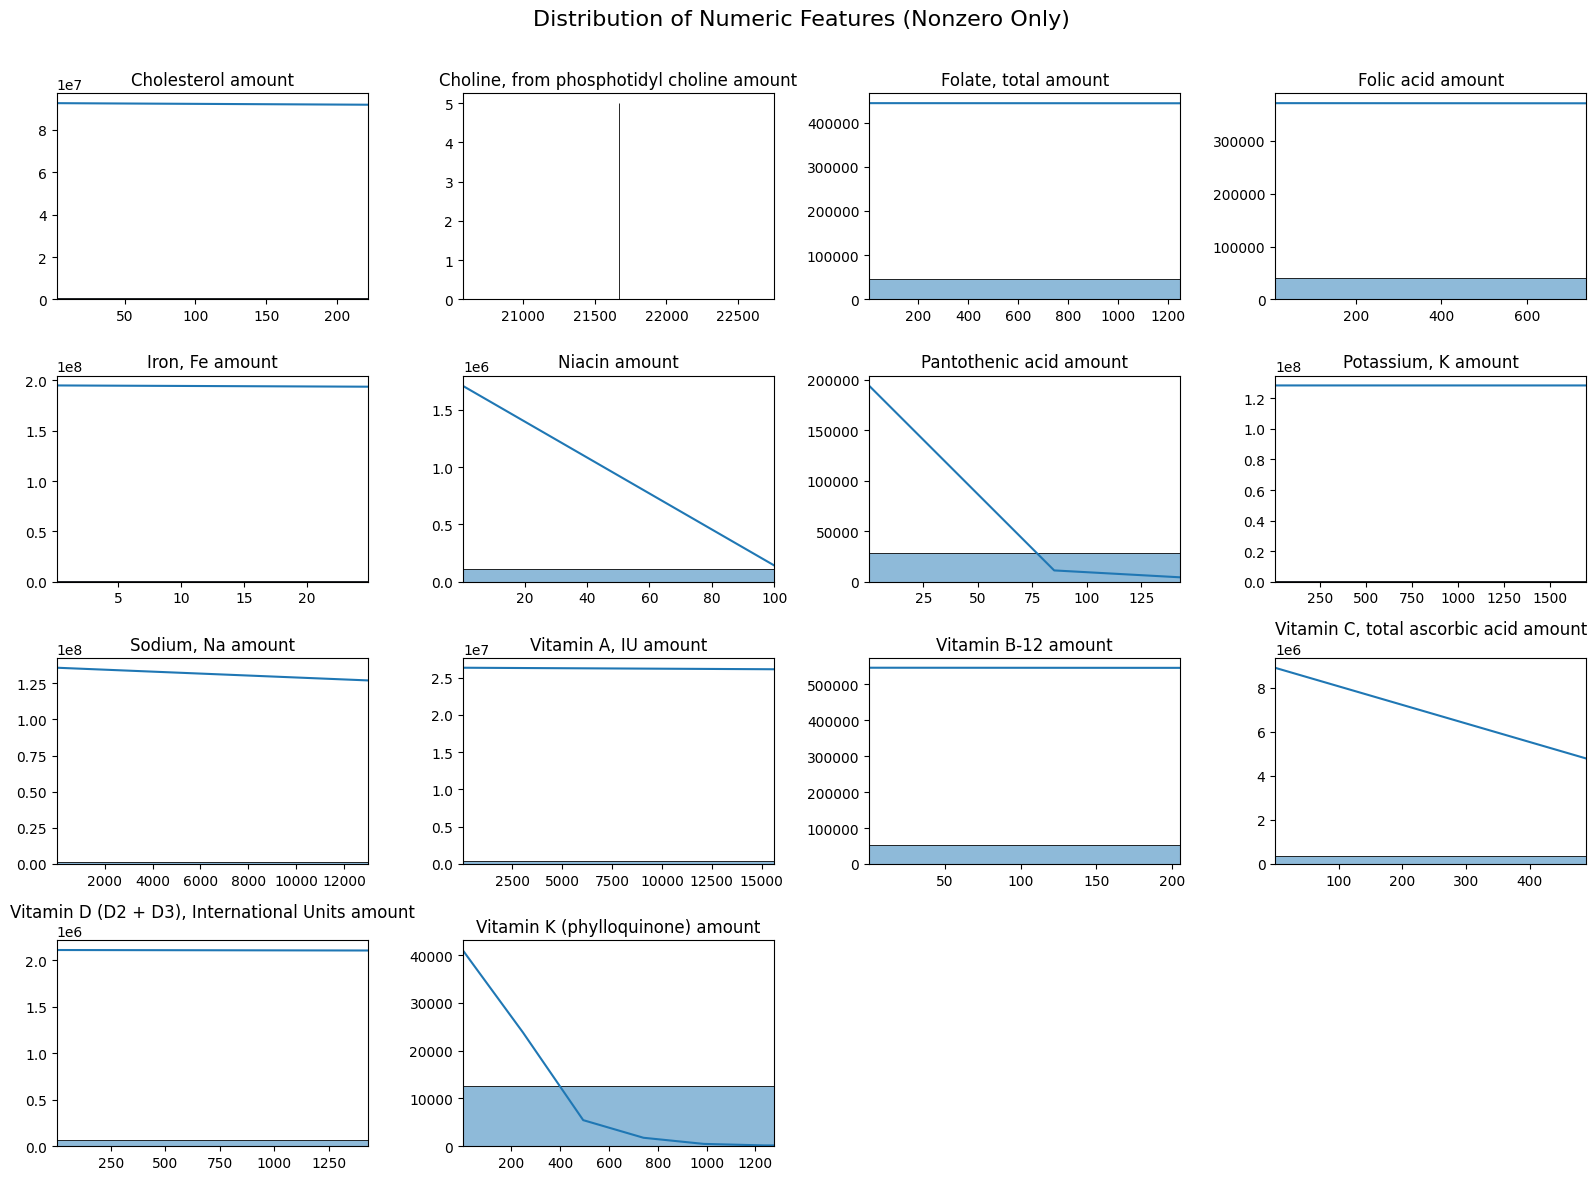

In [ ]:
# Numeric features: all float columns (excluding zeros and embeddings), shown in a grid
numeric_cols = [
    col for col in final_food_data.columns
    if (final_food_data[col].dtype == 'float64' or final_food_data[col].dtype == 'int64')
    and col != 'fdc_id' and col != 'material_code'
    and '_emb' not in col
]
n = len(numeric_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = final_food_data[final_food_data[col] > 0][col]
    if not data.empty:
        # Exclude outliers in the window
        q_low, q_high = np.percentile(data, [1, 99])
        sns.histplot(data, bins=30, kde=True, ax=ax)
        ax.set_xlim(q_low, q_high)
        ax.set_title(f"{col}")
    ax.set_xlabel('')
    ax.set_ylabel('')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle('Distribution of Numeric Features', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

From this we can see quite a few nutrients are very sparse in the data. In the model, we will resolve this by dropping many columns with over 90% zero values.

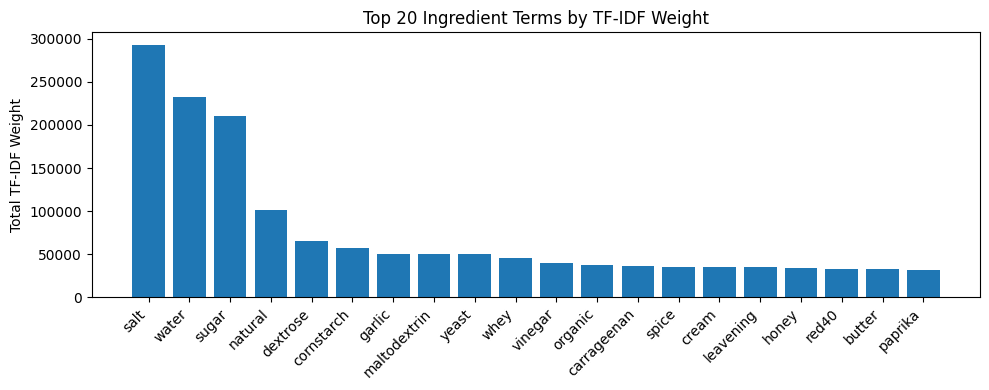

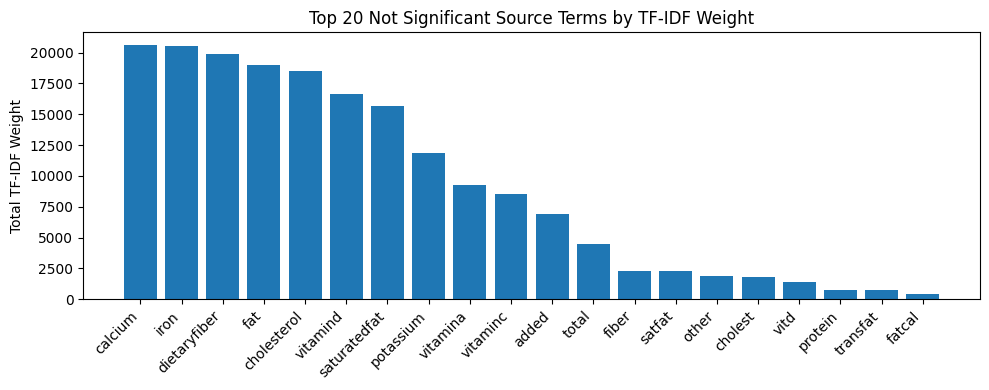

In [292]:
# Plot the sum of TF-IDF weights for each ingredient and not significant source term (top 20)
ingredient_terms = np.array(ingredient_vectorizer.get_feature_names_out())
ingredient_sums = np.asarray(ingredient_vectorizer.transform(ingredient_texts).sum(axis=0)).flatten()
top_ingredient_idx = ingredient_sums.argsort()[::-1][:20]
plt.figure(figsize=(10, 4))
plt.bar(ingredient_terms[top_ingredient_idx], ingredient_sums[top_ingredient_idx])
plt.title('Top 20 Ingredient Terms by TF-IDF Weight')
plt.ylabel('Total TF-IDF Weight')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

not_significant_terms = np.array(not_significant_vectorizer.get_feature_names_out())
not_significant_sums = np.asarray(not_significant_vectorizer.transform(not_significant_texts).sum(axis=0)).flatten()
top_not_significant_idx = not_significant_sums.argsort()[::-1][:20]
plt.figure(figsize=(10, 4))
plt.bar(not_significant_terms[top_not_significant_idx], not_significant_sums[top_not_significant_idx])
plt.title('Top 20 Not Significant Source Terms by TF-IDF Weight')
plt.ylabel('Total TF-IDF Weight')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

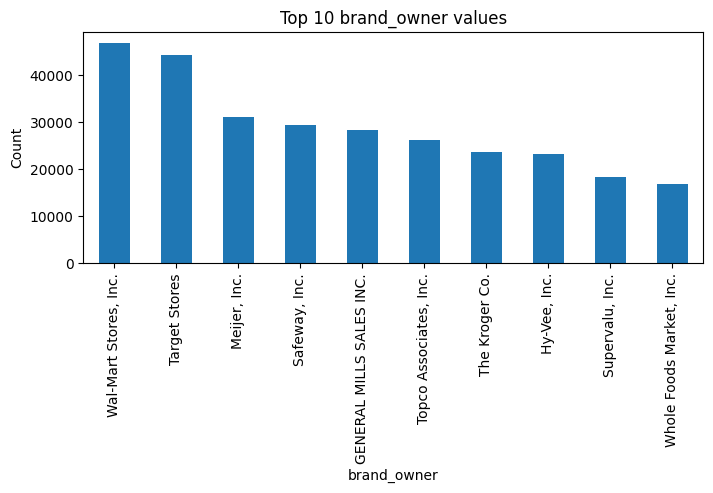

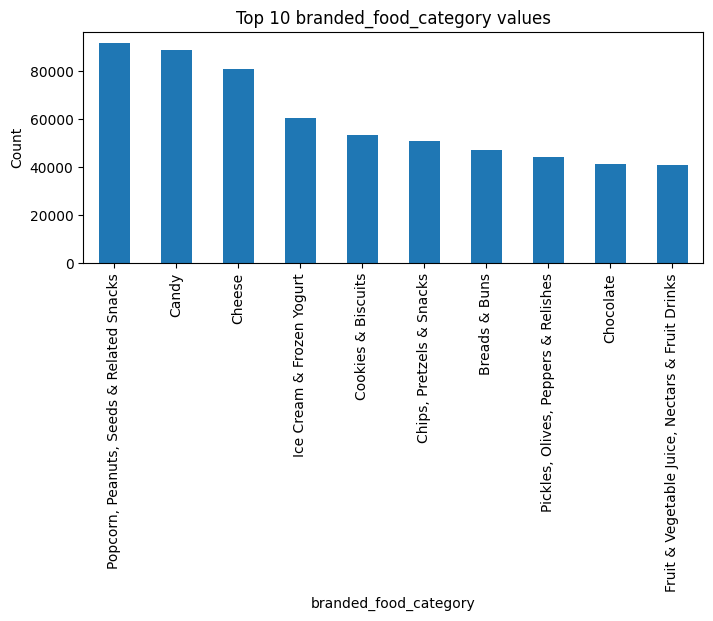

In [293]:
# Categorical features: brand_owner, branded_food_category
for col in ['brand_owner', 'branded_food_category']:
    if col in final_food_data.columns:
        value_counts = final_food_data[final_food_data[col] != 'None'][col].value_counts().head(10)
        plt.figure(figsize=(8, 3))
        value_counts.plot(kind='bar')
        plt.title(f'Top 10 {col} values')
        plt.ylabel('Count')
        plt.show()

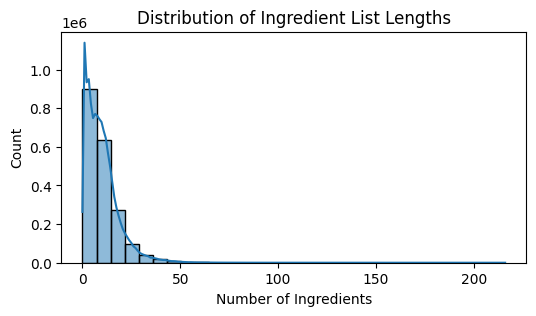

In [294]:
# Ingredients: Length of ingredient lists
final_food_data['ingredient_count'] = final_food_data['parsed_ingredients'].apply(len)
final_food_data['not_significant_count'] = final_food_data['parsed_not_significant'].apply(len)

plt.figure(figsize=(6, 3))
sns.histplot(final_food_data['ingredient_count'], bins=30, kde=True)
plt.title('Distribution of Ingredient List Lengths')
plt.xlabel('Number of Ingredients')
plt.ylabel('Count')
plt.show()

The graph of ingredient list lengths put most entries at 0-1 but scaling up to around 50

### Bivariate Analysis
Bivariate analysis examines the relationships and correlations between features.

First, let's create a correlation heatmap for all of the nutrient amount to see which ones are highly correlated. We will also print the top 5 most corrlated pairs.

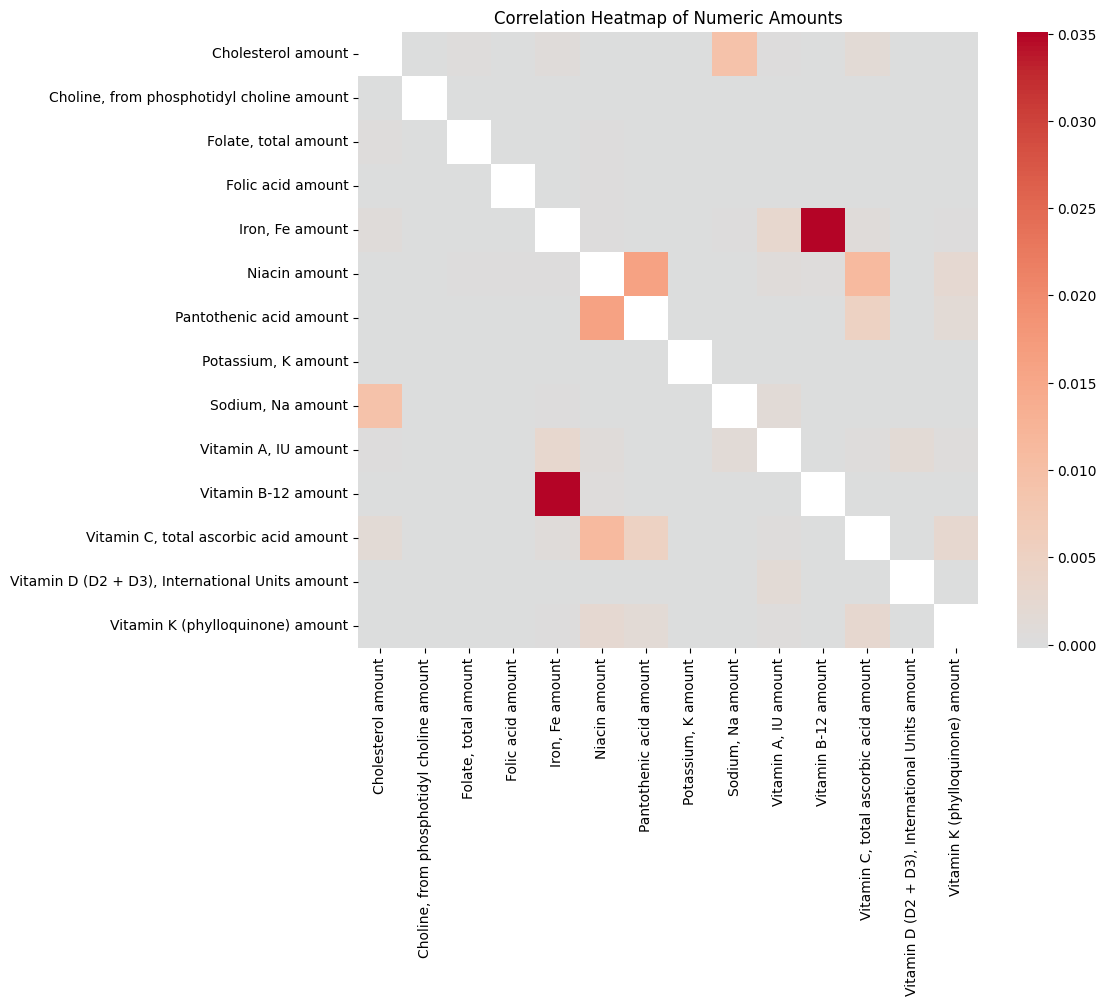

Top 5 Correlated Numeric Pairs
Vitamin B-12 amount                    Iron, Fe amount                          0.035096
Niacin amount                          Pantothenic acid amount                  0.015950
Vitamin C, total ascorbic acid amount  Niacin amount                            0.011222
Cholesterol amount                     Sodium, Na amount                        0.009265
Pantothenic acid amount                Vitamin C, total ascorbic acid amount    0.004977
dtype: float64

Top 5 Least Correlated Numeric Pairs
Iron, Fe amount                        Folic acid amount                                  4.814671e-07
Potassium, K amount                    Vitamin D (D2 + D3), International Units amount    7.238844e-07
                                       Choline, from phosphotidyl choline amount          8.425257e-07
Vitamin C, total ascorbic acid amount  Vitamin D (D2 + D3), International Units amount    9.904912e-07
Vitamin A, IU amount                   Vitamin B-12 amount 

In [295]:
# Correlation heatmap for numeric features (only relevant correlations: 0 < |corr| < 1)
corr = final_food_data[numeric_cols].corr()
# Mask self-correlations and perfect correlations
mask = (corr.abs() == 1)
corr_masked = corr.mask(mask)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_masked, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Numeric Amounts')
plt.show()

# Top 5 correlated features (absolute correlation)
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[(corr_pairs < 1) & (corr_pairs > 0)]
top_pairs = corr_pairs.drop_duplicates().head(5)
print("Top 5 Correlated Numeric Pairs")
print(top_pairs)

# Least correlated features (absolute correlation)
corr_pairs_asc = corr.abs().unstack().sort_values(ascending=True)
corr_pairs_asc = corr_pairs_asc[(corr_pairs_asc < 1) & (corr_pairs_asc > 0)]
least_pairs = corr_pairs_asc.drop_duplicates().head(5)
print("\nTop 5 Least Correlated Numeric Pairs")
print(least_pairs)

Next, we will examine the relation between nutrition and ingredients. For simplicity, we have only done correlations between the count of list items and 5 most common nutrients.

In [ ]:
# Correlation between ingredient count and each nutrient
ingredient_count_corr = {col: final_food_data[col].corr(final_food_data['ingredient_count']) for col in numeric_cols}
print("\nCorrelation between ingredient count and each nutrient:")
print(pd.Series(ingredient_count_corr).sort_values(key=abs, ascending=False))

# Correlation between not significant count and each nutrient
not_significant_count_corr = {col: final_food_data[col].corr(final_food_data['not_significant_count']) for col in numeric_cols}
print("\nCorrelation between not significant source count and each nutrient:")
print(pd.Series(not_significant_count_corr).sort_values(key=abs, ascending=False))

def filter_constant_columns(df):
    return df.loc[:, df.std(axis=0, skipna=True) > 0]

# Find top 5 numeric_cols with most nonzero entries
nonzero_counts = {col: (final_food_data[col] != 0).sum() for col in numeric_cols}
top_numeric_cols = sorted(nonzero_counts, key=nonzero_counts.get, reverse=True)[:5]
print("\nTop 5 numeric columns by nonzero count:")
print(top_numeric_cols)

top_n = 100
ingredient_terms = np.array(ingredient_vectorizer.get_feature_names_out())
ingredient_sums = np.asarray(ingredient_vectorizer.transform(ingredient_texts).sum(axis=0)).flatten()
top_ingredient_idx = ingredient_sums.argsort()[::-1][:top_n]
ingredient_df = pd.DataFrame(ingredient_vectorizer.transform(ingredient_texts)[:, top_ingredient_idx].toarray(), columns=ingredient_terms[top_ingredient_idx])
ingredient_df = filter_constant_columns(ingredient_df)

not_significant_terms = np.array(not_significant_vectorizer.get_feature_names_out())
not_significant_sums = np.asarray(not_significant_vectorizer.transform(not_significant_texts).sum(axis=0)).flatten()
top_not_significant_idx = not_significant_sums.argsort()[::-1][:top_n]
not_significant_df = pd.DataFrame(not_significant_vectorizer.transform(not_significant_texts)[:, top_not_significant_idx].toarray(), columns=not_significant_terms[top_not_significant_idx])
not_significant_df = filter_constant_columns(not_significant_df)

# Correlate ingredient TF-IDF features with each top numeric column
for col in top_numeric_cols:
    print(f"\nTop 10 ingredient TF-IDF features correlated with {col}:")
    if not ingredient_df.empty:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            ingredient_corr = ingredient_df.corrwith(final_food_data[col])
        print(ingredient_corr.abs().sort_values(ascending=False).head(10))
    else:
        print("No variable ingredient TF-IDF features to correlate.")

# Correlate not significant TF-IDF features with each top numeric column
for col in top_numeric_cols:
    print(f"\nTop 10 not significant source TF-IDF features correlated with {col}:")
    if not not_significant_df.empty:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            not_significant_corr = not_significant_df.corrwith(final_food_data[col])
        print(not_significant_corr.abs().sort_values(ascending=False).head(10))
    else:
        print("No variable not significant TF-IDF features to correlate.")

# Memory cleanup after bivariate analysis
memory_cleanup(['ingredient_df', 'not_significant_df'])


Correlation between ingredient count and each nutrient:
Niacin amount                                      0.010379
Pantothenic acid amount                            0.003818
Sodium, Na amount                                 -0.003028
Cholesterol amount                                -0.001612
Vitamin K (phylloquinone) amount                   0.001395
Choline, from phosphotidyl choline amount         -0.001330
Folic acid amount                                 -0.000984
Vitamin B-12 amount                                0.000947
Iron, Fe amount                                   -0.000884
Potassium, K amount                               -0.000767
Folate, total amount                               0.000735
Vitamin C, total ascorbic acid amount              0.000224
Vitamin D (D2 + D3), International Units amount    0.000168
Vitamin A, IU amount                               0.000117
dtype: float64

Correlation between not significant source count and each nutrient:
Vitamin C, total as

Now a bivariate analysis to show the nutrient means by branded food category.

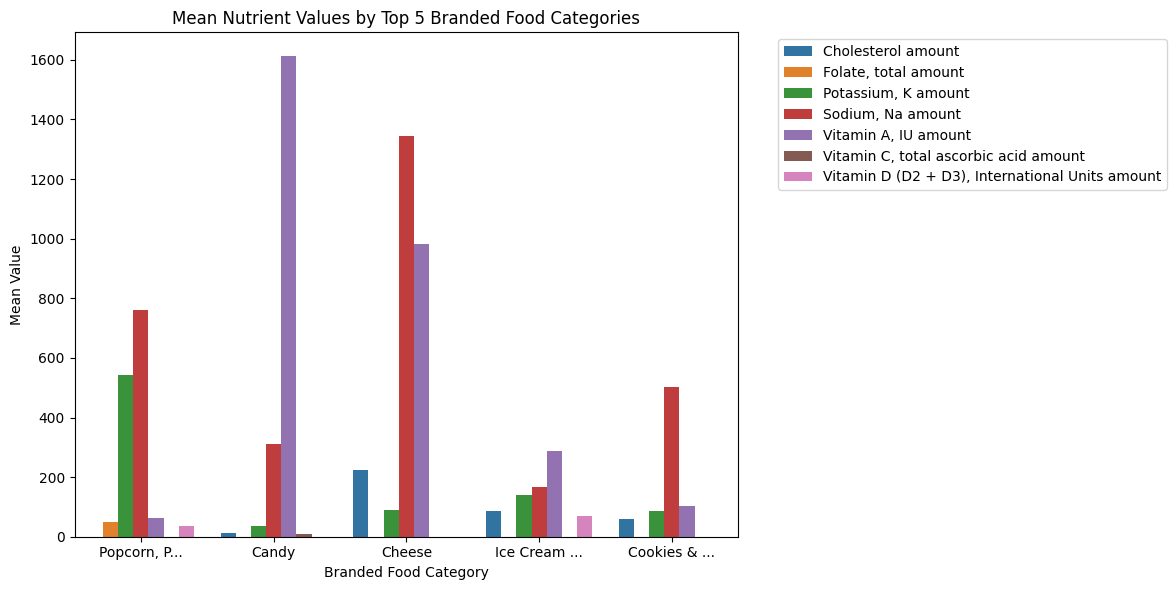

In [ ]:
# Grouped barplot: mean nutrient values by branded_food_category (top 5 categories by count)
if 'branded_food_category' in final_food_data.columns:
    top_categories = final_food_data['branded_food_category'].value_counts().head(5).index
    # Shorten branded_food_category labels to 10 characters + "..."
    def short_label(label):
        label = str(label)
        return label[:10] + "..." if len(label) > 10 else label
    short_cat_map = {cat: short_label(cat) for cat in top_categories}
    group_means = final_food_data[final_food_data['branded_food_category'].isin(top_categories)].groupby('branded_food_category')[numeric_cols].mean()
    group_means = group_means.loc[:, (group_means != 0).any(axis=0)]
    group_means = group_means.applymap(lambda x: x if x >= 10 else 0)
    group_means = group_means.loc[:, (group_means != 0).any(axis=0)]
    group_means_melted = group_means.reset_index().melt(id_vars='branded_food_category', var_name='Nutrient', value_name='Mean Value')
    # Map shortened labels
    group_means_melted['branded_food_category'] = group_means_melted['branded_food_category'].map(short_cat_map)
    short_top_categories = [short_cat_map[cat] for cat in top_categories]
    plt.figure(figsize=(12, 6))
    barplot = sns.barplot(data=group_means_melted, x='branded_food_category', y='Mean Value', hue='Nutrient', order=short_top_categories)
    handles, labels = barplot.get_legend_handles_labels()
    shown_labels = set(group_means_melted['Nutrient'].unique())
    filtered = [(h, l) for h, l in zip(handles, labels) if l in shown_labels]
    if filtered:
        handles, labels = zip(*filtered)
        plt.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        plt.legend([], [], bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Mean Nutrient Values by Top 5 Branded Food Categories')
    plt.ylabel('Mean Value')
    plt.xlabel('Branded Food Category')
    plt.tight_layout()
    plt.show()

An analysis of brand owner and ingredient count.

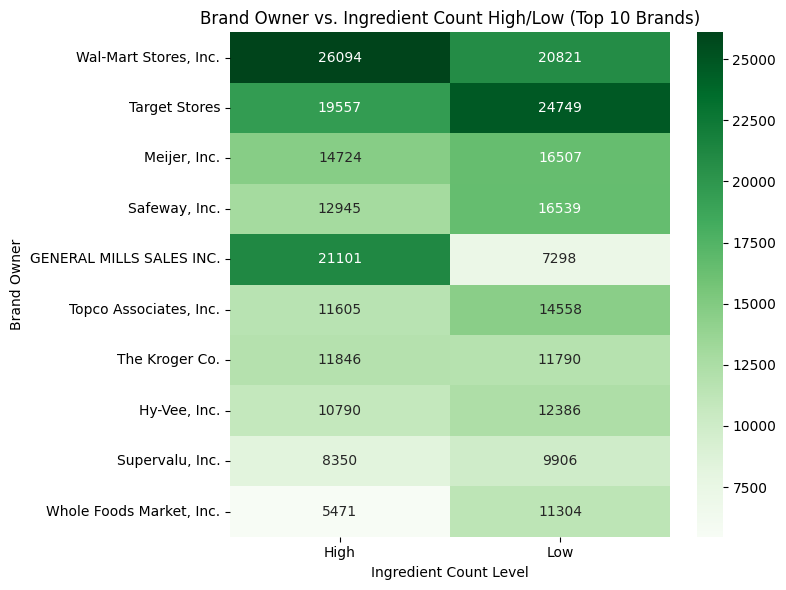

In [298]:
# Cross-tabulation heatmap: brand_owner vs. high/low ingredient count (median split)
if 'brand_owner' in final_food_data.columns:
    median_ingredient_count = final_food_data['ingredient_count'].median()
    final_food_data['ingredient_count_high'] = (final_food_data['ingredient_count'] > median_ingredient_count).map({True: 'High', False: 'Low'})
    filtered_brand_data = final_food_data[final_food_data['brand_owner'] != 'None']
    ctab2 = pd.crosstab(filtered_brand_data['brand_owner'], filtered_brand_data['ingredient_count_high'])
    top_brands = ctab2.sum(axis=1).sort_values(ascending=False).head(10).index
    plt.figure(figsize=(8, 6))
    sns.heatmap(ctab2.loc[top_brands], annot=True, fmt='d', cmap='Greens')
    plt.title('Brand Owner vs. Ingredient Count High/Low (Top 10 Brands)')
    plt.ylabel('Brand Owner')
    plt.xlabel('Ingredient Count Level')
    plt.tight_layout()
    plt.show()
    
# Memory clear
memory_cleanup(['filtered_brand_data', 'ctab2', 'top_brands'])

Finally, a bar plot of mean ingredient count per branded food category.

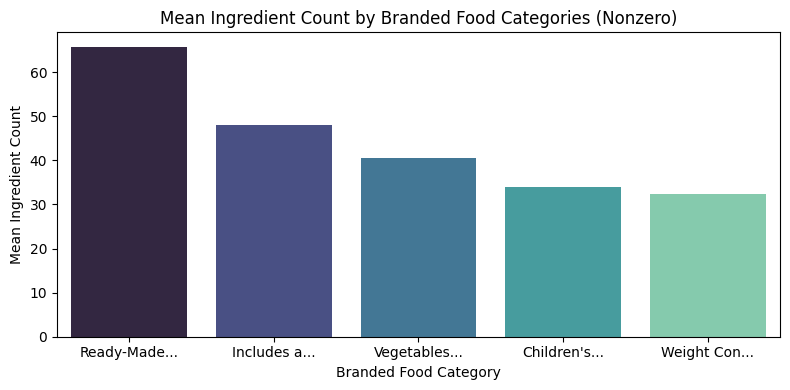

In [299]:
# Barplot: mean ingredient count by branded_food_category (top 5 categories with nonzero mean ingredient count)
if 'branded_food_category' in final_food_data.columns:
    # Compute mean ingredient count per category
    group_ingredient_count = final_food_data.groupby('branded_food_category')['ingredient_count'].mean().reset_index()
    # Filter categories with mean ingredient count > 0
    group_ingredient_count_nonzero = group_ingredient_count[group_ingredient_count['ingredient_count'] > 0]
    # Select top 5 by count (descending)
    top5_nonzero = group_ingredient_count_nonzero.sort_values('ingredient_count', ascending=False).head(5)
    # Shorten labels to 10 chars + "..."
    def short_label(label):
        label = str(label)
        return label[:10] + "..." if len(label) > 10 else label
    top5_nonzero['short_category'] = top5_nonzero['branded_food_category'].map(short_label)
    plt.figure(figsize=(8, 4))
    sns.barplot(data=top5_nonzero, x='short_category', y='ingredient_count', palette='mako', order=top5_nonzero['short_category'])
    plt.title('Mean Ingredient Count by Branded Food Categories (Nonzero)')
    plt.ylabel('Mean Ingredient Count')
    plt.xlabel('Branded Food Category')
    plt.tight_layout()
    plt.show()

### Outlier Detection
Now that we have analyzed some of the feature distributions and correlations, we can start to observe potential outliers in the dataset.

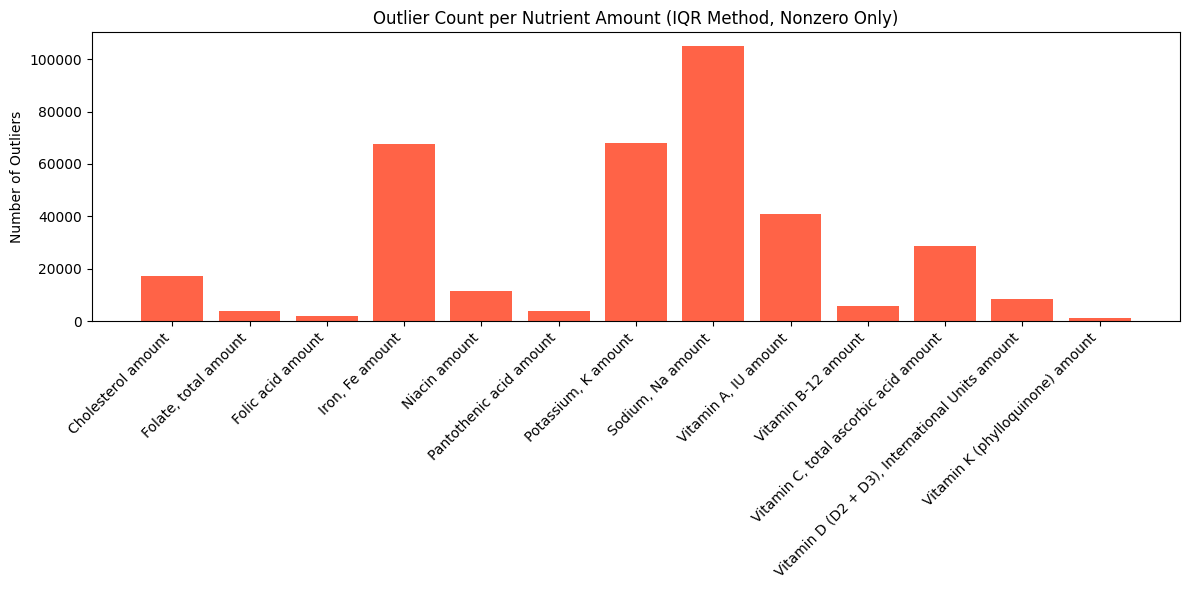

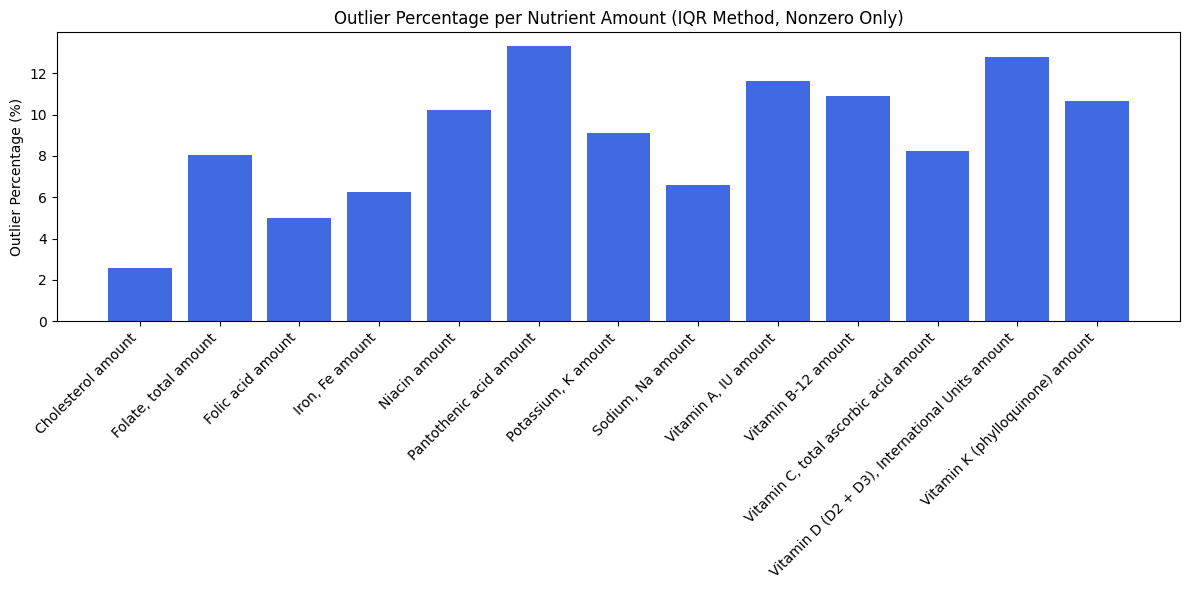

                                           Nutrient  Outlier_Count    Total  \
8                                 Sodium, Na amount         105018  1587959   
7                               Potassium, K amount          67948   747386   
4                                   Iron, Fe amount          67533  1083583   
9                              Vitamin A, IU amount          40810   351338   
11            Vitamin C, total ascorbic acid amount          28532   345869   
0                                Cholesterol amount          17132   671944   
5                                     Niacin amount          11626   113755   
12  Vitamin D (D2 + D3), International Units amount           8597    67109   
10                              Vitamin B-12 amount           5702    52332   
6                           Pantothenic acid amount           3751    28153   

    Outlier_Percentage  
8             6.613395  
7             9.091420  
4             6.232379  
9            11.615595  
11   

In [300]:
# Outlier Detection for Nutrient Amounts
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound), lower_bound, upper_bound

# Find all nutrient amount columns
detected_outliers = {}
outlier_counts = []
nutrient_bounds = {}
for col in numeric_cols:
    # Only consider nonzero values for outlier detection
    nonzero = final_food_data[col][final_food_data[col] > 0]
    if not nonzero.empty:
        outliers, lower, upper = detect_outliers_iqr(nonzero)
        detected_outliers[col] = outliers
        outlier_counts.append({'Nutrient': col, 'Outlier_Count': outliers.sum(), 'Total': len(nonzero)})
        nutrient_bounds[col] = (lower, upper)
    else:
        outlier_counts.append({'Nutrient': col, 'Outlier_Count': 0, 'Total': 0})

outlier_df = pd.DataFrame(outlier_counts)
outlier_df['Outlier_Percentage'] = (outlier_df['Outlier_Count'] / outlier_df['Total']).fillna(0) * 100

# Filter out nutrients with very low outliers for plots (to be perceptible)
outlier_df_nonzero = outlier_df[outlier_df['Outlier_Count'] > 500]

# Visualize the number and percentage of outliers for each nutrient (filtered)
plt.figure(figsize=(12, 6))
plt.bar(outlier_df_nonzero['Nutrient'], outlier_df_nonzero['Outlier_Count'], color='tomato', label='Outlier Count')
plt.ylabel('Number of Outliers')
plt.xticks(rotation=45, ha='right')
plt.title('Outlier Count per Nutrient Amount (IQR Method, Nonzero Only)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(outlier_df_nonzero['Nutrient'], outlier_df_nonzero['Outlier_Percentage'], color='royalblue', label='Outlier %')
plt.ylabel('Outlier Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.title('Outlier Percentage per Nutrient Amount (IQR Method, Nonzero Only)')
plt.tight_layout()
plt.show()

# Show the top 10 nutrients with the highest outlier count (table)
print(outlier_df_nonzero.sort_values('Outlier_Count', ascending=False).head(10))

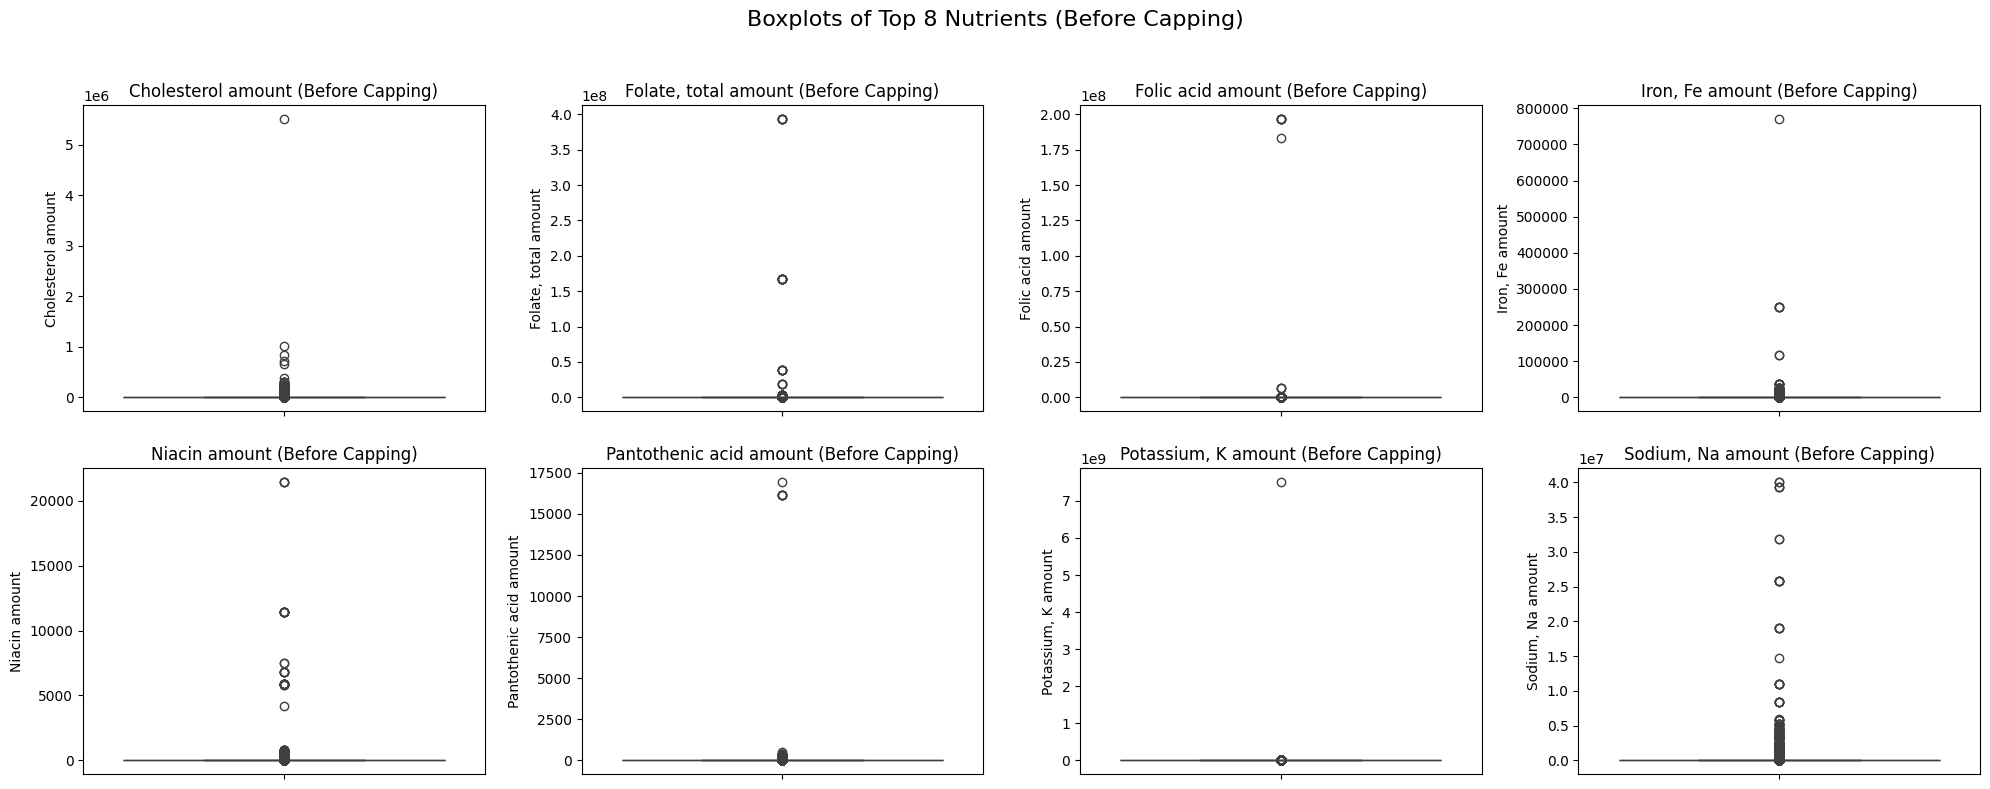

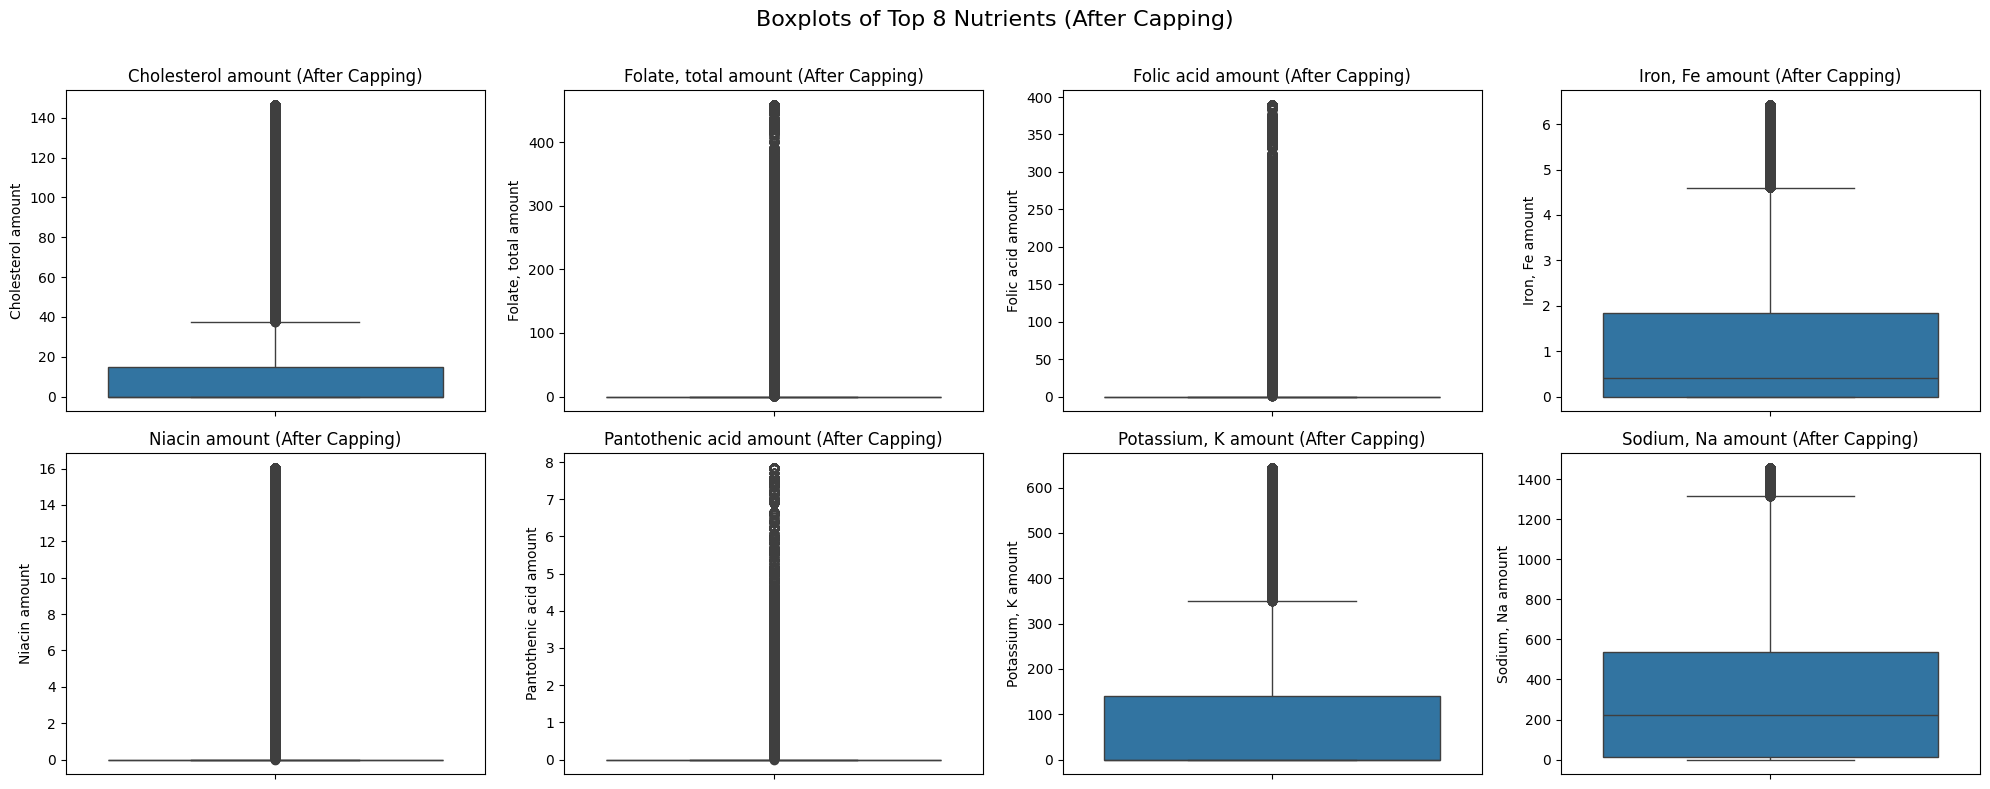

In [301]:
# Plot boxplots before capping for top 8 nutrients (grouped in one figure)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(outlier_df_nonzero['Nutrient'][:8]):
    sns.boxplot(y=final_food_data[col], ax=axes[i])
    axes[i].set_title(f'{col} (Before Capping)')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle('Boxplots of Top 8 Nutrients (Before Capping)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Cap outliers for all nutrient columns
for col, (lower, upper) in nutrient_bounds.items():
    final_food_data.loc[final_food_data[col] < lower, col] = lower
    final_food_data.loc[final_food_data[col] > upper, col] = upper

# Plot boxplots after capping for top 8 nutrients (grouped in one figure)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(outlier_df_nonzero['Nutrient'][:8]):
    sns.boxplot(y=final_food_data[col], ax=axes[i])
    axes[i].set_title(f'{col} (After Capping)')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle('Boxplots of Top 8 Nutrients (After Capping)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Ingredient count outliers: 64153 out of 1977398 (3.24%)
Not significant source count outliers: 79452 out of 1977398 (4.02%)


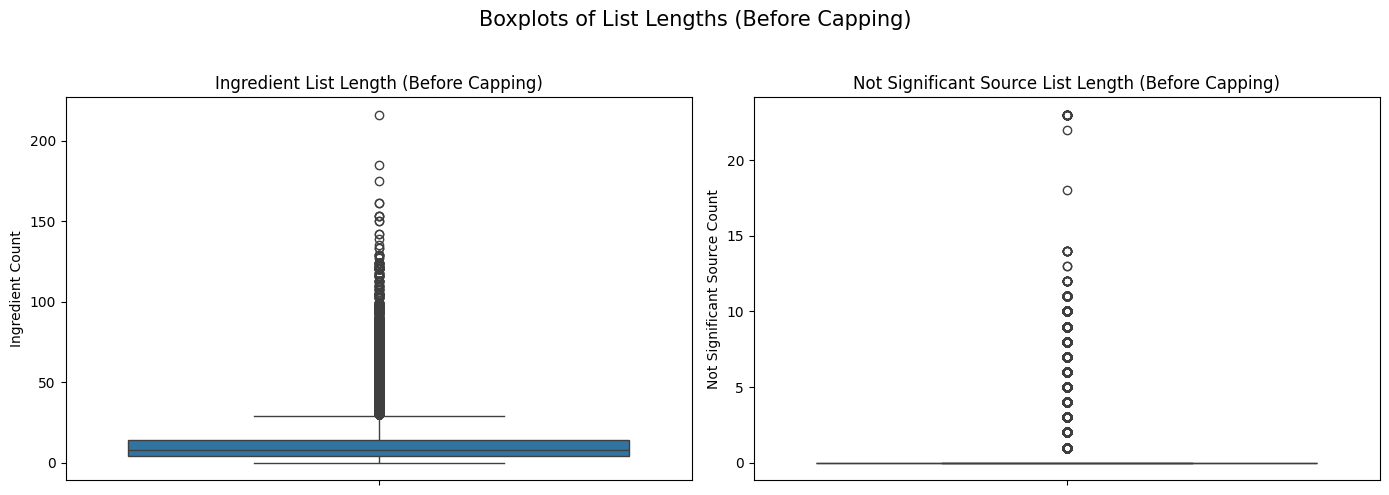

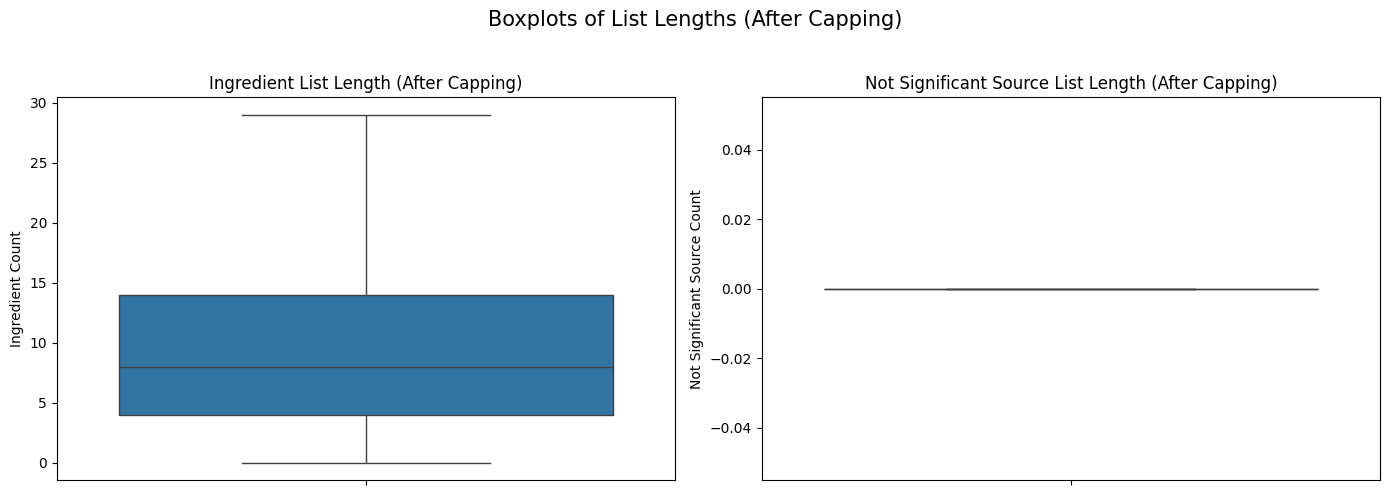

In [302]:
# Outlier Detection and Separate Boxplots for Ingredient and Not Significant Source Lengths (with Outlier Percentage)

# Outlier detection for ingredient_count and not_significant_count
ingredient_outliers, ingredient_lower, ingredient_upper = detect_outliers_iqr(final_food_data['ingredient_count'])
not_significant_outliers, not_significant_lower, not_significant_upper = detect_outliers_iqr(final_food_data['not_significant_count'])

ingredient_outlier_pct = 100 * ingredient_outliers.sum() / len(ingredient_outliers)
not_significant_outlier_pct = 100 * not_significant_outliers.sum() / len(not_significant_outliers)

print(f"Ingredient count outliers: {ingredient_outliers.sum()} out of {len(ingredient_outliers)} ({ingredient_outlier_pct:.2f}%)")
print(f"Not significant source count outliers: {not_significant_outliers.sum()} out of {len(not_significant_outliers)} ({not_significant_outlier_pct:.2f}%)")

# Plot boxplots before capping for ingredient_count and not_significant_count (grouped)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=final_food_data['ingredient_count'], ax=axes[0])
axes[0].set_title('Ingredient List Length (Before Capping)')
axes[0].set_ylabel('Ingredient Count')
sns.boxplot(y=final_food_data['not_significant_count'], ax=axes[1])
axes[1].set_title('Not Significant Source List Length (Before Capping)')
axes[1].set_ylabel('Not Significant Source Count')
fig.suptitle('Boxplots of List Lengths (Before Capping)', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Cap outliers using calculated bounds
final_food_data.loc[final_food_data['ingredient_count'] < ingredient_lower, 'ingredient_count'] = ingredient_lower
final_food_data.loc[final_food_data['ingredient_count'] > ingredient_upper, 'ingredient_count'] = ingredient_upper
final_food_data.loc[final_food_data['not_significant_count'] < not_significant_lower, 'not_significant_count'] = not_significant_lower
final_food_data.loc[final_food_data['not_significant_count'] > not_significant_upper, 'not_significant_count'] = not_significant_upper

# Plot boxplots after capping for ingredient_count and not_significant_count (grouped)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=final_food_data['ingredient_count'], ax=axes[0])
axes[0].set_title('Ingredient List Length (After Capping)')
axes[0].set_ylabel('Ingredient Count')
sns.boxplot(y=final_food_data['not_significant_count'], ax=axes[1])
axes[1].set_title('Not Significant Source List Length (After Capping)')
axes[1].set_ylabel('Not Significant Source Count')
fig.suptitle('Boxplots of List Lengths (After Capping)', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Memory cleanup
memory_cleanup(['ingredient_outliers', 'not_significant_outliers'])

## Step 2: Feature Engineering

### Feature Extraction
The first thing we will do in feature engineering is finding new features to create from pre-existing ones, and add them to a new dataframe. Later we will merge this one with the food data.

subbrand_name and brand_name both depend on brand_owner. Instead we should combine the brand info into a central brand column.

This way once we encode it, we can have a similar category applied to 2 entries of the same combination of brands

In [303]:
# Data before combining brand columns that do not have 'None' or NaN values
def not_none_or_nan(series):
    return (~series.isna()) & (series != 'None')

brand_mask = not_none_or_nan(final_food_data['brand_owner']) & \
             not_none_or_nan(final_food_data['brand_name']) & \
             not_none_or_nan(final_food_data['subbrand_name'])

# Show unique combinations of brand_owner, brand_name, subbrand_name
unique_combos = final_food_data.loc[brand_mask, ['brand_owner', 'brand_name', 'subbrand_name']].drop_duplicates()
unique_combo_indices = unique_combos.index[:10]  # Get row indices of first 10 unique combos

# Display corresponding rows in final_food_data
display(final_food_data.loc[unique_combo_indices, ['brand_owner', 'brand_name', 'subbrand_name']])

,brand_owner,brand_name,subbrand_name
359012,CAMPBELL SOUP COMPANY,V8,V-FUSION
359014,CAMPBELL SOUP COMPANY,CAMPBELL'S,CONDENSED
359016,CAMPBELL SOUP COMPANY,CAMPBELL'S,CHUNKY
359021,CAMPBELL SOUP COMPANY,CAMPBELL'S,HOMESTYLE
359048,CAMPBELL SOUP COMPANY,CAMPBELL'S,HEALTHY REQUEST
359052,CAMPBELL SOUP COMPANY,CAMPBELL'S,SLOW KETTLE
359060,CAMPBELL SOUP COMPANY,V8,SPLASH
359355,CAMPBELL SOUP COMPANY,CAMPBELL'S,SOUP ON THE GO
359726,Bush Brothers & Company,Bush's Best,Chili Magic
418027,GENERAL MILLS SALES INC.,Pillsbury,Reese's


In [304]:
# Concatenate subbrand_name, brand_name, and brand_owner into new column 'brand', skipping 'None' and NaN
def concat_brand(row):
    parts = [str(row['brand_owner']), str(row['brand_name']), str(row['subbrand_name'])]
    parts = [p for p in parts if p != 'None' and p != 'nan' and p != '' and pd.notna(p)]
    return ' | '.join(parts) if parts else 'None'

extracted_food_data['brand'] = final_food_data.apply(concat_brand, axis=1)

# Display corresponding rows in extracted_food_data
display(extracted_food_data.loc[unique_combo_indices])

,ingredient_emb_0,not_significant_emb_0,ingredient_emb_1,not_significant_emb_1,ingredient_emb_2,not_significant_emb_2,ingredient_emb_3,not_significant_emb_3,ingredient_emb_4,not_significant_emb_4,ingredient_emb_5,not_significant_emb_5,ingredient_emb_6,not_significant_emb_6,ingredient_emb_7,not_significant_emb_7,ingredient_emb_8,not_significant_emb_8,ingredient_emb_9,not_significant_emb_9,ingredient_emb_10,not_significant_emb_10,ingredient_emb_11,not_significant_emb_11,ingredient_emb_12,not_significant_emb_12,ingredient_emb_13,not_significant_emb_13,ingredient_emb_14,not_significant_emb_14,ingredient_emb_15,not_significant_emb_15,ingredient_emb_16,not_significant_emb_16,ingredient_emb_17,not_significant_emb_17,ingredient_emb_18,not_significant_emb_18,ingredient_emb_19,not_significant_emb_19,ingredient_emb_20,not_significant_emb_20,ingredient_emb_21,not_significant_emb_21,ingredient_emb_22,not_significant_emb_22,ingredient_emb_23,not_significant_emb_23,ingredient_emb_24,not_significant_emb_24,ingredient_emb_25,not_significant_emb_25,ingredient_emb_26,not_significant_emb_26,ingredient_emb_27,not_significant_emb_27,ingredient_emb_28,not_significant_emb_28,ingredient_emb_29,not_significant_emb_29,ingredient_emb_30,not_significant_emb_30,ingredient_emb_31,not_significant_emb_31,ingredient_emb_32,not_significant_emb_32,ingredient_emb_33,not_significant_emb_33,ingredient_emb_34,not_significant_emb_34,ingredient_emb_35,not_significant_emb_35,ingredient_emb_36,not_significant_emb_36,ingredient_emb_37,not_significant_emb_37,ingredient_emb_38,not_significant_emb_38,ingredient_emb_39,not_significant_emb_39,ingredient_emb_40,not_significant_emb_40,ingredient_emb_41,not_significant_emb_41,ingredient_emb_42,not_significant_emb_42,ingredient_emb_43,not_significant_emb_43,ingredient_emb_44,not_significant_emb_44,ingredient_emb_45,not_significant_emb_45,ingredient_emb_46,not_significant_emb_46,ingredient_emb_47,not_significant_emb_47,ingredient_emb_48,not_significant_emb_48,ingredient_emb_49,not_significant_emb_49,brand
359012,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,CAMPBELL SOUP COMPANY | V8 | V-FUSION
359014,0.291553,0.0,0.060066,0.0,-0.086181,0.0,-0.016310,0.0,0.118420,0.0,0.016570,0.0,-0.004205,0.0,-0.012704,0.0,0.048632,0.0,-0.042240,0.0,0.292362,0.0,0.088249,0.0,-0.012410,0.0,0.017023,0.0,-0.013453,0.0,0.041488,0.0,-0.091344,0.0,-0.086614,0.0,-0.013528,0.0,-0.000529,0.0,0.016092,0.0,-0.057441,0.0,-0.033803,0.0,0.030266,0.0,-0.009183,0.0,-0.008397,0.0,-0.010611,0.0,-0.028539,0.0,0.049677,0.0,-0.006284,0.0,0.002991,0.0,0.012651,0.0,0.002980,0.0,0.003285,0.0,0.079511,0.0,-0.021695,0.0,0.005120,0.0,-0.019236,0.0,0.030462,0.0,0.028438,0.0,0.025306,0.0,0.016103,0.0,0.024864,0.0,0.020158,0.0,0.021124,0.0,-0.006923,0.0,0.092781,0.0,0.272800,0.0,0.045567,0.0,0.023539,0.0,CAMPBELL SOUP COMPANY | CAMPBELL'S | CONDENSED
359016,0.325131,0.0,0.046832,0.0,0.067027,0.0,-0.057507,0.0,0.037165,0.0,-0.006161,0.0,0.044463,0.0,0.112050,0.0,-0.059002,0.0,-0.019690,0.0,-0.085936,0.0,0.097998,0.0,0.055052,0.0,-0.012119,0.0,-0.003525,0.0,0.011692,0.0,-0.004907,0.0,-0.116553,0.0,-0.184755,0.0,0.200102,0.0,-0.187939,0.0,-0.216251,0.0,0.020548,0.0,-0.129131,0.0,0.208367,0.0,0.005477,0.0,0.013186,0.0,0.025204,0.0,0.165265,0.0,-0.048167,0.0,-0.019746,0.0,-0.041675,0.0,0.019054,0.0,-0.014310,0.0,0.063333,0.0,-0.028297,0.0,0.039173,0.0,-0.023339,0.0,0.143653,0.0,0.104816,0

Next, we can try to extract some data from the description and short_description column by getting their lengths

In [305]:
# Add columns desc_length and short_desc_length to extracted_food_data
extracted_food_data['desc_length'] = final_food_data['description'].apply(lambda x: len(x) if x != 'None' else 0)
extracted_food_data['short_desc_length'] = final_food_data['short_description'].apply(lambda x: len(x) if x != 'None' else 0)

extracted_food_data.head(10)

,ingredient_emb_0,not_significant_emb_0,ingredient_emb_1,not_significant_emb_1,ingredient_emb_2,not_significant_emb_2,ingredient_emb_3,not_significant_emb_3,ingredient_emb_4,not_significant_emb_4,ingredient_emb_5,not_significant_emb_5,ingredient_emb_6,not_significant_emb_6,ingredient_emb_7,not_significant_emb_7,ingredient_emb_8,not_significant_emb_8,ingredient_emb_9,not_significant_emb_9,ingredient_emb_10,not_significant_emb_10,ingredient_emb_11,not_significant_emb_11,ingredient_emb_12,not_significant_emb_12,ingredient_emb_13,not_significant_emb_13,ingredient_emb_14,not_significant_emb_14,ingredient_emb_15,not_significant_emb_15,ingredient_emb_16,not_significant_emb_16,ingredient_emb_17,not_significant_emb_17,ingredient_emb_18,not_significant_emb_18,ingredient_emb_19,not_significant_emb_19,ingredient_emb_20,not_significant_emb_20,ingredient_emb_21,not_significant_emb_21,ingredient_emb_22,not_significant_emb_22,ingredient_emb_23,not_significant_emb_23,ingredient_emb_24,not_significant_emb_24,ingredient_emb_25,not_significant_emb_25,ingredient_emb_26,not_significant_emb_26,ingredient_emb_27,not_significant_emb_27,ingredient_emb_28,not_significant_emb_28,ingredient_emb_29,not_significant_emb_29,ingredient_emb_30,not_significant_emb_30,ingredient_emb_31,not_significant_emb_31,ingredient_emb_32,not_significant_emb_32,ingredient_emb_33,not_significant_emb_33,ingredient_emb_34,not_significant_emb_34,ingredient_emb_35,not_significant_emb_35,ingredient_emb_36,not_significant_emb_36,ingredient_emb_37,not_significant_emb_37,ingredient_emb_38,not_significant_emb_38,ingredient_emb_39,not_significant_emb_39,ingredient_emb_40,not_significant_emb_40,ingredient_emb_41,not_significant_emb_41,ingredient_emb_42,not_significant_emb_42,ingredient_emb_43,not_significant_emb_43,ingredient_emb_44,not_significant_emb_44,ingredient_emb_45,not_significant_emb_45,ingredient_emb_46,not_significant_emb_46,ingredient_emb_47,not_significant_emb_47,ingredient_emb_48,not_significant_emb_48,ingredient_emb_49,not_significant_emb_49,brand,desc_length,short_desc_length
0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,Richardson Oilseed Products (US) Limited,26,0
1,0.689188,0.0,-0.591901,0.0,-0.385769,0.0,0.053686,0.0,-0.097564,0.0,-0.021951,0.0,-0.073331,0.0,0.024882,0.0,0.056649,0.0,-0.008466,0.0,0.009531,0.0,-0.013389,0.0,0.005004,0.0,-0.012431,0.0,0.008136,0.0,0.018354,0.0,-0.014802,0.0,-0.001809,0.0,-0.009339,0.0,-0.017070,0.0,-0.005455,0.0,-0.003201,0.0,0.001544,0.0,-0.004413,0.0,-0.004327,0.0,0.001517,0.0,0.010116,0.0,0.003860,0.0,-0.012884,0.0,-0.028598,0.0,-0.000413,0.0,-0.000507,0.0,-0.001901,0.0,-0.007998,0.0,-0.005602,0.0,-0.006689,0.0,0.000421,0.0,0.001215,0.0,0.000078,0.0,-0.002640,0.0,-0.004975,0.0,-0.009324,0.0,0.009312,0.0,-0.004823,0.0,-0.010461,0.0,-0.011790,0.0,-0.009252,0.0,-0.005488,0.0,-0.002849,0.0,-0.005342,0.0,CAMPBELL SOUP COMPANY,18,0
2,0.227972,0.0,-0.108418,0.0,0.114919,0.0,-0.054238,0.0,-0.000654,0.0,-0.000574,0.0,0.004203,0.0,0.165274,0.0,-0.077524,0.0,0.008113,0.0,-0.044250,0.0,0.009783,0.0,-0.042332,0.0,-0.019154,0.0,0.042210,0.0,-0.008584,0.0,-0.041066,0.0,-0.153874,0.0,-0.025834,0.0,0.001168,0.0,-0.044107,0.0,0.071154,0.0,-0.099373,0.0,0.058668,0.0,-0.041812,0.0,0.005763,0.0,-0.038280,0.0,-0.072629,0.0,0.191841,0.0,-0.013116,0.0,-0.078167,0.0,0.108505,0.0,0.246096,0.0,-0.042058,0.0,0.046415,0.0,0.023835,0.0,0.015746,0.0,-0.002420,0.0,0.147

We can also add log transform for nutrient amounts.

Our nutrient distributions are highly skewed because of the clustering torwards 0 with some outliers, so adding this to our model gives it raw and normalized perspectives of the data.

In [306]:
# Efficient log transform for all skewed columns (added to extracted_food_data)
skewed_cols = [col for col in numeric_cols if abs(final_food_data[col].skew()) > 1]

# Remove any previously added log columns to avoid duplication on re-execution
log_cols_to_remove = [col for col in extracted_food_data.columns if col.endswith('_log') and col.replace('_log', '') in numeric_cols]
if log_cols_to_remove:
    extracted_food_data.drop(columns=log_cols_to_remove, inplace=True)
log_transformed = {}
for col in skewed_cols:
    log_transformed[f'{col}_log'] = np.where(final_food_data[col] > 0, np.log1p(final_food_data[col]), 0)
if log_transformed:
    extracted_food_data = pd.concat([extracted_food_data, pd.DataFrame(log_transformed, index=final_food_data.index)], axis=1)

print(f"Log-transformed columns: {skewed_cols}")

Log-transformed columns: ['Cholesterol amount', 'Folate, total amount', 'Folic acid amount', 'Iron, Fe amount', 'Niacin amount', 'Pantothenic acid amount', 'Potassium, K amount', 'Sodium, Na amount', 'Vitamin A, IU amount', 'Vitamin B-12 amount', 'Vitamin C, total ascorbic acid amount', 'Vitamin D (D2 + D3), International Units amount', 'Vitamin K (phylloquinone) amount']


### Feature Selection
Before merging the new features into food data, lets make some room in the dataframe by performing feature selection, removing irrelavant features

In [307]:
final_food_data.head()

,fdc_id,data_type,description,publication_date,market_country_x,trade_channel_x,microbe_data,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients,not_a_significant_source_of,serving_size,serving_size_unit,household_serving_fulltext,branded_food_category,data_source,package_weight,modified_date,available_date,market_country_y,discontinued_date,preparation_state_code,trade_channel_y,short_description,material_code,Acetic acid amount,Alanine amount,"Alcohol, ethyl amount",Arginine amount,Ash amount,Aspartic acid amount,Beta-glucans amount,Biotin amount,Caffeine amount,"Calcium, Ca amount","Carbohydrate, by difference amount","Carbohydrate, other amount","Carotene, beta amount","Chlorine, Cl amount",Cholesterol amount,"Choline, from phosphotidyl choline amount","Choline, total amount","Chromium, Cr amount","Copper, Cu amount",Cysteine amount,Cystine amount,Energy amount,Epigallocatechin-3-gallate amount,"Fatty acids, total monounsaturated amount","Fatty acids, total polyunsaturated amount","Fatty acids, total saturated amount","Fatty acids, total trans amount","Fiber, insoluble amount","Fiber, soluble amount","Fiber, total dietary amount","Fluoride, F amount","Folate, DFE amount","Folate, food amount","Folate, total amount",Folic acid amount,Fructose amount,Glucose amount,Glutamic acid amount,Glutamine amount,Glycine amount,Histidine amount,Inositol amount,Inulin amount,"Iodine, I amount","Iron, Fe amount",Isoleucine amount,Lactic acid amount,Lactose amount,Leucine amount,Lignin amount,Lutein + zeaxanthin amount,Lysine amount,"Magnesium, Mg amount","Manganese, Mn amount",Methionine amount,"Molybdenum, Mo amount",Niacin amount,PUFA 18:2 amount,"PUFA 18:2 n-6 c,c amount","PUFA 18:3 n-3 c,c,c (ALA) amount",Pantothenic acid amount,Phenylalanine amount,"Phosphorus, P amount","Potassium, K amount",Proline amount,Protein amount,Retinol amount,Riboflavin amount,Ribose amount,SFA 10:0 amount,SFA 12:0 amount,SFA 22:0 amount,SFA 8:0 amount,"Salt, NaCl amount","Selenium, Se amount",Serine amount,"Sodium, Na amount",Sorbitol amount,Starch amount,"Sugars, Total amount","Sugars, added amount","Sugars, intrinsic amount",Taurine amount,Thiamin amount,Threonine amount,Total Sugars amount,Total lipid (fat) amount,Total sugar alcohols amount,Tryptophan amount,Tyrosine amount,Valine amount,Vitamin A amount,"Vitamin A, IU amount","Vitamin A, RAE amount",Vitamin B-12 amount,Vitamin B-6 amount,"Vitamin C, total ascorbic acid amount",Vitamin D (D2 + D3) amount,"Vitamin D (D2 + D3), International Units amount",Vitamin D2 (ergocalciferol) amount,Vitamin D3 (cholecalciferol) amount,Vitamin E amount,Vitamin E (alpha-tocopherol) amount,Vitamin E (label entry primarily) amount,Vitamin K (phylloquinone) amount,Water amount,Xylitol amount,"Zinc, Zn amount",Acetic acid unit,Alanine unit,"Alcohol, ethyl unit",Arginine unit,Ash unit,Aspartic acid unit,Beta-glucans unit,Biotin unit,Caffeine unit,"Calcium, Ca unit","Carbohydrate, by difference unit","Carbohydrate, other unit","Carotene, beta unit","Chlorine, Cl unit",Cholesterol unit,"Choline, from phosphotidyl choline unit","Choline, total unit","Chromium, Cr unit","Copper, Cu unit",Cysteine unit,Cystine unit,Energy unit,Epigallocatechin-3-gallate unit,"Fatty acids, total monounsaturated unit","Fatty acids, total polyunsaturated unit","Fatty acids, total saturated unit","Fatty acids, total trans unit","Fiber, insoluble unit","Fiber, soluble unit","Fiber, total dietary unit","Fluoride, F unit","Folate, DFE unit","Folate, food unit","Folate, total unit",Folic acid unit,Fructose unit,Glucose unit,Glutamic acid unit,Glutamine unit,Glycine unit,Histidine unit,Inositol unit,Inulin unit,"Iodine, I unit","Iron, Fe unit",Isoleucine unit,Lactic acid unit,Lactose unit,Leucine unit,Lignin unit,Lutein + zeaxanthin unit,Lysine unit,"Magnesium, Mg unit","Manganese, Mn unit",Methionine unit,"Molybdenum, Mo unit",Niacin unit,PUFA 18:2 unit,"PUFA 18:2 n-6 c,c unit","PUFA 18:3 n-3 c,c,c (ALA) unit",Pantothenic acid unit,Phenylalan

The first method of ellimination is domain knowledge, removing any columns which would realistically not have an imact on the nutrients or ingredients.

Below are reasons why some features are not relevant for ingredient/nutrient prediction:

1. **trade_channel_x / trade_channel_y**: These describe the sales or distribution channel and do not provide information about the food's composition or nutrients.
2. **household_serving_fulltext**: Serving size is already provided as well as the unit, the fulltext is not needed.
3. **modified_date / discontinued_date**: These are administrative fields about when the product was last modified or discontinued, not about its ingredients or nutrients.
4. **preparation_state_code**: Indicates the state of the food (e.g., frozen, fresh), which may not directly affect the ingredient list or nutrient content for prediction purposes.
5. **material_code**: Internal or logistical code, not related to food composition.
6. **gtin_upc**: Global Trade Item Number, provides no value alongside fdc_id which is already used to identify each food item.
7. **description**: Description length already extracted.
8. **short_description**: Short description length extracted.
9. **ingredients, not_a_significant_source_of, parsed_not_significant**: Has been used for embeddings already, parsed_ingredients will be used in one-hot encodings later before being dropped.

In [ ]:
# Drop irrelevant columns
irrelevant_columns = [
    'trade_channel_x', 'trade_channel_y', 'household_serving_fulltext', 'modified_date',
    'discontinued_date', 'preparation_state_code', 'material_code', 'gtin_upc', 'description',
    'short_description', 'ingredients', 'not_a_significant_source_of', 'parsed_not_significant'
 ]
final_food_data = final_food_data.drop(columns=[col for col in irrelevant_columns if col in final_food_data.columns])

The next method for finding columns to be dropped will be to analyze columns with low unique values

In [309]:
# Print unique value counts for columns besides fdc_id, ingredients, and all nutrient amounts/units
columns_to_print = [
    'data_type', 'publication_date', 'market_country_x', 'microbe_data', 'serving_size', 'serving_size_unit', 'branded_food_category',
    'data_source', 'available_date', 'market_country_y'
 ]
seen = set()
unique_columns = []
for col in columns_to_print:
    if col not in seen:
        unique_columns.append(col)
        seen.add(col)
for col in unique_columns:
    if col in final_food_data.columns:
        print(f"{col}: {final_food_data[col].nunique()} unique values")
    else:
        print(f"{col}: Column not found in DataFrame.")

data_type: 1 unique values
publication_date: 61 unique values
market_country_x: 2 unique values
microbe_data: 4 unique values
serving_size: 1814 unique values
serving_size_unit: 8 unique values
branded_food_category: 448 unique values
data_source: 3 unique values
available_date: 61 unique values
market_country_y: 2 unique values


In [310]:
# Print all unique values for the columns with less than 10 unique values
for col in unique_columns:
    if col in final_food_data.columns:
        unique_values = final_food_data[col].unique()
        if len(unique_values) < 10:
            print(f"\nUnique values for column '{col}':")
            print(unique_values)


Unique values for column 'data_type':
['branded_food']
Categories (2, object): ['branded_food', 'None']

Unique values for column 'market_country_x':
['United States', 'New Zealand']
Categories (3, object): ['New Zealand', 'United States', 'None']

Unique values for column 'microbe_data':
['[{"min_value":null,"uom":null,"microbe_method..., '[{"min_value":10000000,"uom":null,"microbe_me..., '[{"min_value":10000000,"uom":"X_CFG","microbe..., '[{"min_value":10000000,"uom":"X_CFG","microbe...]
Categories (5, object): ['[{"min_value":10000000,"uom":"X_CFG","microbe..., '[{"min_value":10000000,"uom":"X_CFG","microbe..., '[{"min_value":10000000,"uom":null,"microbe_me..., '[{"min_value":null,"uom":null,"microbe_method..., 'None']

Unique values for column 'serving_size_unit':
['ml', 'g', 'GRM', 'MLT', 'MG', 'IU', 'GM', 'MC']
Categories (9, object): ['GM', 'GRM', 'IU', 'MC', ..., 'MLT', 'g', 'ml', 'None']

Unique values for column 'data_source':
['GDSN', 'LI', 'NZGDSN']
Categories (4, object):

From this, we can conclude that:
1. data_type is not needed because it only has one possible value
2. market_country_x, market_country_y, and data_source only serve to explain where the data came from and is not needed.
3. microbe_data is incomplete and should be dropped.
4. publication_date and available_date are for when the data was published and is not needed.

In [311]:
# Drop irrelevant columns
irrelevant_columns = ['fdc_id', 'data_type', 'market_country_x', 'market_country_y', 'data_source', 'microbe_data',
                      'publication_date', 'available_date']
final_food_data = final_food_data.drop(columns=[col for col in irrelevant_columns if col in final_food_data.columns])

### Merge Datasets
Merging the extracted features with the food data

In [312]:
extracted_food_data.head()
extracted_food_data = reduce_memory_usage(extracted_food_data)

In [313]:
final_food_data.head()
final_food_data = reduce_memory_usage(final_food_data)

In [314]:
# Now merge extracted_food_data into final_food_data
final_food_data = pd.concat([final_food_data, extracted_food_data], axis=1)
final_food_data.head()

memory_cleanup(['extracted_food_data'])

### Feature Transformation
Feature transformation involves modifying already existing columns. One tranformation we can perform is by looking at serving size unit and unit columns for each nutrient

In [315]:
# Display serving_size_unit possible values
print(np.unique(final_food_data['serving_size_unit']))

# Display all unique values from nutrient unit columns
unit_columns = [col for col in final_food_data.columns if 'unit' in col and col != 'serving_size_unit']
all_units = set()
for col in unit_columns:
    all_units.update(final_food_data[col].unique())
print(np.array(sorted(all_units)))

['GM' 'GRM' 'IU' 'MC' 'MG' 'MLT' 'g' 'ml']
['G' 'IU' 'KCAL' 'MG' 'MG_ATE' 'UG' 'kJ']


From this information, we can conclude that some of these units can be standardized, for example MG and UG converting to G. We will start with serving_size_unit

In [316]:
# Standardize serving_size and serving_size_unit to ['g', 'ml', 'IU']
def standardize_serving_size(row):
    unit = str(row['serving_size_unit']).upper()
    size = row['serving_size']
    try:
        size = float(size)
    except:
        return pd.Series({'serving_size': np.nan, 'serving_size_unit': 'None'})
    # MG, MC -> g (divide by 1000)
    if unit in ['MG', 'MC']:
        return pd.Series({'serving_size': size / 1000, 'serving_size_unit': 'g'})
    # GM, GRM, G -> g
    elif unit in ['GM', 'GRM', 'G']:
        return pd.Series({'serving_size': size, 'serving_size_unit': 'g'})
    # MLT, ML -> ml
    elif unit in ['MLT', 'ML']:
        return pd.Series({'serving_size': size, 'serving_size_unit': 'ml'})
    # IU -> IU
    elif unit == 'IU':
        return pd.Series({'serving_size': size, 'serving_size_unit': 'IU'})
    # Unknown unit
    else:
        return pd.Series({'serving_size': np.nan, 'serving_size_unit': 'None'})

final_food_data[['serving_size', 'serving_size_unit']] = final_food_data.apply(standardize_serving_size, axis=1)

print(final_food_data['serving_size_unit'].value_counts())
print(final_food_data[['serving_size', 'serving_size_unit']].head())

serving_size_unit
g     1705620
ml     268111
IU       3667
Name: count, dtype: int64
   serving_size serving_size_unit
0          15.0                ml
1         240.0                ml
2         440.0                 g
3         440.0                 g
4         240.0                ml


In [317]:
# Standardize each nutrient amount to its common unit

nutrient_unit_cols = [col for col in final_food_data.columns if 'unit' in col and col != 'serving_size_unit']

# Ensure all needed categories exist before assignment
for unit_col in nutrient_unit_cols:
    if pd.api.types.is_categorical_dtype(final_food_data[unit_col]):
        needed_cats = ['G', 'KCAL', 'IU', 'None']
        current_cats = final_food_data[unit_col].cat.categories
        new_cats = [cat for cat in needed_cats if cat not in current_cats]
        if new_cats:
            final_food_data[unit_col] = final_food_data[unit_col].cat.add_categories(new_cats)

for unit_col in nutrient_unit_cols:
    amount_col = unit_col.replace('unit', 'amount')
    if amount_col not in final_food_data.columns:
        continue
    units = final_food_data[unit_col].astype(str).str.upper()
    amounts = final_food_data[amount_col].astype(float)
    # Convert MG and MG_ATE to G
    mg_mask = (units == 'MG') | (units == 'MG_ATE')
    final_food_data.loc[mg_mask, amount_col] = amounts[mg_mask] / 1000
    final_food_data.loc[mg_mask, unit_col] = 'G'
    # Convert UG to G
    ug_mask = units == 'UG'
    final_food_data.loc[ug_mask, amount_col] = amounts[ug_mask] / 1e6
    final_food_data.loc[ug_mask, unit_col] = 'G'
    # Convert kJ to KCAL
    kj_mask = units == 'KJ'
    final_food_data.loc[kj_mask, amount_col] = amounts[kj_mask] / 4.184
    final_food_data.loc[kj_mask, unit_col] = 'KCAL'
    # Leave rest unchanged
    known_units = ['G', 'KCAL', 'IU']
    unknown_mask = ~units.isin(known_units + ['MG', 'UG', 'MG_ATE', 'KJ'])
    final_food_data.loc[unknown_mask, amount_col] = np.nan
    final_food_data.loc[unknown_mask, unit_col] = 'None'

# Verify standardization
all_units = set()
for col in nutrient_unit_cols:
    all_units.update(final_food_data[col].unique())
print(np.array(sorted(all_units)))

['G' 'IU' 'KCAL']


There are certain methods we can use to convert IU and KCAL to grams, but we have to know what these nutrients are first.

In [318]:
# Display nutrient units that are IU or KCAL
for unit_type in ['IU', 'KCAL']:
    print(f"\nNutrient amounts with unit {unit_type}:")
    for unit_col in nutrient_unit_cols:
        amount_col = unit_col.replace('unit', 'amount')
        if amount_col in final_food_data.columns:
            mask = final_food_data[unit_col] == unit_type
            count = mask.sum()
            if count > 0:
                print(f"{amount_col} ({unit_col})")


Nutrient amounts with unit IU:
Vitamin A, IU amount (Vitamin A, IU unit)
Vitamin D (D2 + D3), International Units amount (Vitamin D (D2 + D3), International Units unit)
Vitamin E (label entry primarily) amount (Vitamin E (label entry primarily) unit)

Nutrient amounts with unit KCAL:
Energy amount (Energy unit)


In [ ]:
# Convert Vitamin A, IU amount to grams
vitamin_a_mask = final_food_data['Vitamin A, IU unit'] == 'IU'
final_food_data.loc[vitamin_a_mask, 'Vitamin A, IU amount'] = final_food_data.loc[vitamin_a_mask, 'Vitamin A, IU amount'] * 0.0003
final_food_data.loc[vitamin_a_mask, 'Vitamin A, IU unit'] = 'G'

# Convert Vitamin D (D2 + D3), International Units amount to grams
vitamin_d_mask = final_food_data['Vitamin D (D2 + D3), International Units unit'] == 'IU'
final_food_data.loc[vitamin_d_mask, 'Vitamin D (D2 + D3), International Units amount'] = final_food_data.loc[vitamin_d_mask, 'Vitamin D (D2 + D3), International Units amount'] * 0.000025
final_food_data.loc[vitamin_d_mask, 'Vitamin D (D2 + D3), International Units unit'] = 'G'

# Convert Vitamin E (label entry primarily) amount from IU to G
vitamin_e_mask = final_food_data['Vitamin E (label entry primarily) unit'] == 'IU'
final_food_data.loc[vitamin_e_mask, 'Vitamin E (label entry primarily) amount'] = final_food_data.loc[vitamin_e_mask, 'Vitamin E (label entry primarily) amount'] * 0.00067
final_food_data.loc[vitamin_e_mask, 'Vitamin E (label entry primarily) unit'] = 'G'

# Convert Energy amount from KCAL to G
energy_mask = final_food_data['Energy unit'] == 'KCAL'
final_food_data.loc[energy_mask, 'Energy amount'] = final_food_data.loc[energy_mask, 'Energy amount'] * 0.001
final_food_data.loc[energy_mask, 'Energy unit'] = 'G'

In [320]:
# Verify standardization
all_units = set()
for col in nutrient_unit_cols:
    all_units.update(final_food_data[col].unique())
print(np.array(sorted(all_units)))

['G' 'IU']


Now that we have identified any abnormal units and standardized them, we no longer have a use for the nutrient unit columns because they should all now be the same, in grams.

In [321]:
# Drop nutrient unit columns after standardization
final_food_data = final_food_data.drop(columns=nutrient_unit_cols)

Now let's modify the package weight column, as we can see below it has the weight and the unit of measure in the same field. Let's separate them into different columns.

In [322]:
# Data where package_weight is not string 'None'
final_food_data[final_food_data['package_weight'] != 'None'].head()

,brand_owner,brand_name,subbrand_name,serving_size,serving_size_unit,branded_food_category,package_weight,Acetic acid amount,Alanine amount,"Alcohol, ethyl amount",Arginine amount,Ash amount,Aspartic acid amount,Beta-glucans amount,Biotin amount,Caffeine amount,"Calcium, Ca amount","Carbohydrate, by difference amount","Carbohydrate, other amount","Carotene, beta amount","Chlorine, Cl amount",Cholesterol amount,"Choline, from phosphotidyl choline amount","Choline, total amount","Chromium, Cr amount","Copper, Cu amount",Cysteine amount,Cystine amount,Energy amount,Epigallocatechin-3-gallate amount,"Fatty acids, total monounsaturated amount","Fatty acids, total polyunsaturated amount","Fatty acids, total saturated amount","Fatty acids, total trans amount","Fiber, insoluble amount","Fiber, soluble amount","Fiber, total dietary amount","Fluoride, F amount","Folate, DFE amount","Folate, food amount","Folate, total amount",Folic acid amount,Fructose amount,Glucose amount,Glutamic acid amount,Glutamine amount,Glycine amount,Histidine amount,Inositol amount,Inulin amount,"Iodine, I amount","Iron, Fe amount",Isoleucine amount,Lactic acid amount,Lactose amount,Leucine amount,Lignin amount,Lutein + zeaxanthin amount,Lysine amount,"Magnesium, Mg amount","Manganese, Mn amount",Methionine amount,"Molybdenum, Mo amount",Niacin amount,PUFA 18:2 amount,"PUFA 18:2 n-6 c,c amount","PUFA 18:3 n-3 c,c,c (ALA) amount",Pantothenic acid amount,Phenylalanine amount,"Phosphorus, P amount","Potassium, K amount",Proline amount,Protein amount,Retinol amount,Riboflavin amount,Ribose amount,SFA 10:0 amount,SFA 12:0 amount,SFA 22:0 amount,SFA 8:0 amount,"Salt, NaCl amount","Selenium, Se amount",Serine amount,"Sodium, Na amount",Sorbitol amount,Starch amount,"Sugars, Total amount","Sugars, added amount","Sugars, intrinsic amount",Taurine amount,Thiamin amount,Threonine amount,Total Sugars amount,Total lipid (fat) amount,Total sugar alcohols amount,Tryptophan amount,Tyrosine amount,Valine amount,Vitamin A amount,"Vitamin A, IU amount","Vitamin A, RAE amount",Vitamin B-12 amount,Vitamin B-6 amount,"Vitamin C, total ascorbic acid amount",Vitamin D (D2 + D3) amount,"Vitamin D (D2 + D3), International Units amount",Vitamin D2 (ergocalciferol) amount,Vitamin D3 (cholecalciferol) amount,Vitamin E amount,Vitamin E (alpha-tocopherol) amount,Vitamin E (label entry primarily) amount,Vitamin K (phylloquinone) amount,Water amount,Xylitol amount,"Zinc, Zn amount",parsed_ingredients,ingredient_count,not_significant_count,ingredient_count_high,ingredient_emb_0,not_significant_emb_0,ingredient_emb_1,not_significant_emb_1,ingredient_emb_2,not_significant_emb_2,ingredient_emb_3,not_significant_emb_3,ingredient_emb_4,not_significant_emb_4,ingredient_emb_5,not_significant_emb_5,ingredient_emb_6,not_significant_emb_6,ingredient_emb_7,not_significant_emb_7,ingredient_emb_8,not_significant_emb_8,ingredient_emb_9,not_significant_emb_9,ingredient_emb_10,not_significant_emb_10,ingredient_emb_11,not_significant_emb_11,ingredient_emb_12,not_significant_emb_12,ingredient_emb_13,not_significant_emb_13,ingredient_emb_14,not_significant_emb_14,ingredient_emb_15,not_significant_emb_15,ingredient_emb_16,not_significant_emb_16,ingredient_emb_17,not_significant_emb_17,ingredient_emb_18,not_significant_emb_18,ingredient_emb_19,not_significant_emb_19,ingredient_emb_20,not_significant_emb_20,ingredient_emb_21,not_significant_emb_21,ingredient_emb_22,not_significant_emb_22,ingredient_emb_23,not_significant_emb_23,ingredient_emb_24,not_significant_emb_24,ingredient_emb_25,not_significant_emb_25,ingredient_emb_26,not_significant_emb_26,ingredient_emb_27,not_significant_emb_27,ingredient_emb_28,not_significant_emb_28,ingredient_emb_29,not_significant_emb_29,ingredient_emb_30,not_significant_emb_30,ingredient_emb_31,not_significant_emb_31,ingredient_emb_32,not_significant_emb_32,ingredient_emb_33,not_significant_emb_33,ingredient_emb_34,not_significant_emb_34,ingredient_emb_35,not_significant_emb_35,ingr

In [323]:
# Separate package_weight into numeric and unit columns
def split_package_weight(row):
    weight = row['package_weight']
    if weight == 'None' or pd.isna(weight):
        return pd.Series({'package_weight_amount': 0, 'package_weight_unit': 'None'})
    # Extract first valid float and unit using regex
    match = re.match(r'([0-9]*\.?[0-9]+)\s*([a-zA-Z]+)', weight)
    if match:
        num_str = match.group(1)
        unit = match.group(2).upper()
        try:
            amount = float(num_str)
        except ValueError:
            amount = 0
            unit = 'None'
        return pd.Series({'package_weight_amount': amount, 'package_weight_unit': unit})
    else:
        return pd.Series({'package_weight_amount': 0, 'package_weight_unit': 'None'})
    
final_food_data[['package_weight_amount', 'package_weight_unit']] = final_food_data.apply(split_package_weight, axis=1)
final_food_data = final_food_data.drop(columns=['package_weight'])
final_food_data[final_food_data['package_weight_amount'] != 0].head()

,brand_owner,brand_name,subbrand_name,serving_size,serving_size_unit,branded_food_category,Acetic acid amount,Alanine amount,"Alcohol, ethyl amount",Arginine amount,Ash amount,Aspartic acid amount,Beta-glucans amount,Biotin amount,Caffeine amount,"Calcium, Ca amount","Carbohydrate, by difference amount","Carbohydrate, other amount","Carotene, beta amount","Chlorine, Cl amount",Cholesterol amount,"Choline, from phosphotidyl choline amount","Choline, total amount","Chromium, Cr amount","Copper, Cu amount",Cysteine amount,Cystine amount,Energy amount,Epigallocatechin-3-gallate amount,"Fatty acids, total monounsaturated amount","Fatty acids, total polyunsaturated amount","Fatty acids, total saturated amount","Fatty acids, total trans amount","Fiber, insoluble amount","Fiber, soluble amount","Fiber, total dietary amount","Fluoride, F amount","Folate, DFE amount","Folate, food amount","Folate, total amount",Folic acid amount,Fructose amount,Glucose amount,Glutamic acid amount,Glutamine amount,Glycine amount,Histidine amount,Inositol amount,Inulin amount,"Iodine, I amount","Iron, Fe amount",Isoleucine amount,Lactic acid amount,Lactose amount,Leucine amount,Lignin amount,Lutein + zeaxanthin amount,Lysine amount,"Magnesium, Mg amount","Manganese, Mn amount",Methionine amount,"Molybdenum, Mo amount",Niacin amount,PUFA 18:2 amount,"PUFA 18:2 n-6 c,c amount","PUFA 18:3 n-3 c,c,c (ALA) amount",Pantothenic acid amount,Phenylalanine amount,"Phosphorus, P amount","Potassium, K amount",Proline amount,Protein amount,Retinol amount,Riboflavin amount,Ribose amount,SFA 10:0 amount,SFA 12:0 amount,SFA 22:0 amount,SFA 8:0 amount,"Salt, NaCl amount","Selenium, Se amount",Serine amount,"Sodium, Na amount",Sorbitol amount,Starch amount,"Sugars, Total amount","Sugars, added amount","Sugars, intrinsic amount",Taurine amount,Thiamin amount,Threonine amount,Total Sugars amount,Total lipid (fat) amount,Total sugar alcohols amount,Tryptophan amount,Tyrosine amount,Valine amount,Vitamin A amount,"Vitamin A, IU amount","Vitamin A, RAE amount",Vitamin B-12 amount,Vitamin B-6 amount,"Vitamin C, total ascorbic acid amount",Vitamin D (D2 + D3) amount,"Vitamin D (D2 + D3), International Units amount",Vitamin D2 (ergocalciferol) amount,Vitamin D3 (cholecalciferol) amount,Vitamin E amount,Vitamin E (alpha-tocopherol) amount,Vitamin E (label entry primarily) amount,Vitamin K (phylloquinone) amount,Water amount,Xylitol amount,"Zinc, Zn amount",parsed_ingredients,ingredient_count,not_significant_count,ingredient_count_high,ingredient_emb_0,not_significant_emb_0,ingredient_emb_1,not_significant_emb_1,ingredient_emb_2,not_significant_emb_2,ingredient_emb_3,not_significant_emb_3,ingredient_emb_4,not_significant_emb_4,ingredient_emb_5,not_significant_emb_5,ingredient_emb_6,not_significant_emb_6,ingredient_emb_7,not_significant_emb_7,ingredient_emb_8,not_significant_emb_8,ingredient_emb_9,not_significant_emb_9,ingredient_emb_10,not_significant_emb_10,ingredient_emb_11,not_significant_emb_11,ingredient_emb_12,not_significant_emb_12,ingredient_emb_13,not_significant_emb_13,ingredient_emb_14,not_significant_emb_14,ingredient_emb_15,not_significant_emb_15,ingredient_emb_16,not_significant_emb_16,ingredient_emb_17,not_significant_emb_17,ingredient_emb_18,not_significant_emb_18,ingredient_emb_19,not_significant_emb_19,ingredient_emb_20,not_significant_emb_20,ingredient_emb_21,not_significant_emb_21,ingredient_emb_22,not_significant_emb_22,ingredient_emb_23,not_significant_emb_23,ingredient_emb_24,not_significant_emb_24,ingredient_emb_25,not_significant_emb_25,ingredient_emb_26,not_significant_emb_26,ingredient_emb_27,not_significant_emb_27,ingredient_emb_28,not_significant_emb_28,ingredient_emb_29,not_significant_emb_29,ingredient_emb_30,not_significant_emb_30,ingredient_emb_31,not_significant_emb_31,ingredient_emb_32,not_significant_emb_32,ingredient_emb_33,not_significant_emb_33,ingredient_emb_34,not_significant_emb_34,ingredient_emb_35,not_significant_emb_35,ingredient_emb_36,n

### Feature Encoding
Categorical features need to be encoded into numerical values for efficient use in the model. For this, we can use a label encoder for columns like brand_owner, branded_food_category, and serving_size_unit.

We also want to one-hot encode the ingredient list which indicates whether or not that ingredient is present. In our model, any number of these columns will be our target to predict. Ex: predict if this food item has salt.

In [324]:
# Encode categorical features using LabelEncoder
# Select all object and category columns except 'parsed_ingredients'
obj_cat_cols = [
    col for col in final_food_data.columns
    if ((str(final_food_data[col].dtype) == 'object' or str(final_food_data[col].dtype) == 'category')
        and col != 'parsed_ingredients')
]
label_encoders = {}
for col in obj_cat_cols:
    if col in final_food_data.columns:
        le = LabelEncoder()
        final_food_data[f'{col}_encoded'] = le.fit_transform(final_food_data[col].astype(str))
        label_encoders[col] = le

# Drop the obj_cat columns after encoding
final_food_data = final_food_data.drop(columns=obj_cat_cols)

In [325]:
reduce_memory_usage(final_food_data)
display_column_types(final_food_data)

1. serving_size - float32
2. Acetic acid amount - float32
3. Alanine amount - float32
4. Alcohol, ethyl amount - float32
5. Arginine amount - float32
6. Ash amount - float32
7. Aspartic acid amount - float32
8. Beta-glucans amount - float32
9. Biotin amount - float32
10. Caffeine amount - float32
11. Calcium, Ca amount - float32
12. Carbohydrate, by difference amount - float32
13. Carbohydrate, other amount - float32
14. Carotene, beta amount - float32
15. Chlorine, Cl amount - float32
16. Cholesterol amount - float32
17. Choline, from phosphotidyl choline amount - float32
18. Choline, total amount - float32
19. Chromium, Cr amount - float32
20. Copper, Cu amount - float32
21. Cysteine amount - float32
22. Cystine amount - float32
23. Energy amount - float32
24. Epigallocatechin-3-gallate amount - float32
25. Fatty acids, total monounsaturated amount - float32
26. Fatty acids, total polyunsaturated amount - float32
27. Fatty acids, total saturated amount - float32
28. Fatty acids, tota

In [326]:
# Remove any previously added one-hot columns to avoid duplication on re-execution
ingredient_onehot_cols = [col for col in final_food_data.columns if col.startswith('ingredient_oh_')]
if ingredient_onehot_cols:
    final_food_data.drop(columns=ingredient_onehot_cols, inplace=True)

# Create one-hot columns for top 500 ingredients
for ing in top_ingredients:
    col_name = f'ingredient_oh_{ing}'
    final_food_data[col_name] = final_food_data['parsed_ingredients'].apply(
        lambda lst: np.uint8(ing in lst) if isinstance(lst, list) else np.uint8(0)
    )

print(f"Added {len(top_ingredients)} one-hot ingredient columns (top 500 by frequency).")

if 'parsed_ingredients' in final_food_data.columns:
    final_food_data.drop(columns=['parsed_ingredients'], inplace=True)

Added 500 one-hot ingredient columns (top 500 by frequency).


### Feature Scaling
Now we will perform feature scaling on all numeric columns using StandardScaler. This is because some models are sensitive to some features being higher scaled than others.

In [327]:
# Scale numeric features using StandardScaler
scaler = StandardScaler()

# Select columns to scale
scale_cols = [col for col in numeric_cols if col in final_food_data.columns]

final_food_data[scale_cols] = scaler.fit_transform(final_food_data[scale_cols])

print("Scaled columns:", scale_cols)

Scaled columns: ['Cholesterol amount', 'Choline, from phosphotidyl choline amount', 'Folate, total amount', 'Folic acid amount', 'Iron, Fe amount', 'Niacin amount', 'Pantothenic acid amount', 'Potassium, K amount', 'Sodium, Na amount', 'Vitamin A, IU amount', 'Vitamin B-12 amount', 'Vitamin C, total ascorbic acid amount', 'Vitamin D (D2 + D3), International Units amount', 'Vitamin K (phylloquinone) amount']


### Normalization
Finally we will perform normalization, which is used alongisde scaling to constrict the range of the scaled features to [0,1]

In [328]:
# Normalize scaled features to [0, 1] range using MinMaxScaler
minmax_scaler = MinMaxScaler()

final_food_data[scale_cols] = minmax_scaler.fit_transform(final_food_data[scale_cols])

print("Normalized columns:", scale_cols)
final_food_data.head()

Normalized columns: ['Cholesterol amount', 'Choline, from phosphotidyl choline amount', 'Folate, total amount', 'Folic acid amount', 'Iron, Fe amount', 'Niacin amount', 'Pantothenic acid amount', 'Potassium, K amount', 'Sodium, Na amount', 'Vitamin A, IU amount', 'Vitamin B-12 amount', 'Vitamin C, total ascorbic acid amount', 'Vitamin D (D2 + D3), International Units amount', 'Vitamin K (phylloquinone) amount']


,serving_size,Acetic acid amount,Alanine amount,"Alcohol, ethyl amount",Arginine amount,Ash amount,Aspartic acid amount,Beta-glucans amount,Biotin amount,Caffeine amount,"Calcium, Ca amount","Carbohydrate, by difference amount","Carbohydrate, other amount","Carotene, beta amount","Chlorine, Cl amount",Cholesterol amount,"Choline, from phosphotidyl choline amount","Choline, total amount","Chromium, Cr amount","Copper, Cu amount",Cysteine amount,Cystine amount,Energy amount,Epigallocatechin-3-gallate amount,"Fatty acids, total monounsaturated amount","Fatty acids, total polyunsaturated amount","Fatty acids, total saturated amount","Fatty acids, total trans amount","Fiber, insoluble amount","Fiber, soluble amount","Fiber, total dietary amount","Fluoride, F amount","Folate, DFE amount","Folate, food amount","Folate, total amount",Folic acid amount,Fructose amount,Glucose amount,Glutamic acid amount,Glutamine amount,Glycine amount,Histidine amount,Inositol amount,Inulin amount,"Iodine, I amount","Iron, Fe amount",Isoleucine amount,Lactic acid amount,Lactose amount,Leucine amount,Lignin amount,Lutein + zeaxanthin amount,Lysine amount,"Magnesium, Mg amount","Manganese, Mn amount",Methionine amount,"Molybdenum, Mo amount",Niacin amount,PUFA 18:2 amount,"PUFA 18:2 n-6 c,c amount","PUFA 18:3 n-3 c,c,c (ALA) amount",Pantothenic acid amount,Phenylalanine amount,"Phosphorus, P amount","Potassium, K amount",Proline amount,Protein amount,Retinol amount,Riboflavin amount,Ribose amount,SFA 10:0 amount,SFA 12:0 amount,SFA 22:0 amount,SFA 8:0 amount,"Salt, NaCl amount","Selenium, Se amount",Serine amount,"Sodium, Na amount",Sorbitol amount,Starch amount,"Sugars, Total amount","Sugars, added amount","Sugars, intrinsic amount",Taurine amount,Thiamin amount,Threonine amount,Total Sugars amount,Total lipid (fat) amount,Total sugar alcohols amount,Tryptophan amount,Tyrosine amount,Valine amount,Vitamin A amount,"Vitamin A, IU amount","Vitamin A, RAE amount",Vitamin B-12 amount,Vitamin B-6 amount,"Vitamin C, total ascorbic acid amount",Vitamin D (D2 + D3) amount,"Vitamin D (D2 + D3), International Units amount",Vitamin D2 (ergocalciferol) amount,Vitamin D3 (cholecalciferol) amount,Vitamin E amount,Vitamin E (alpha-tocopherol) amount,Vitamin E (label entry primarily) amount,Vitamin K (phylloquinone) amount,Water amount,Xylitol amount,"Zinc, Zn amount",ingredient_count,not_significant_count,ingredient_emb_0,not_significant_emb_0,ingredient_emb_1,not_significant_emb_1,ingredient_emb_2,not_significant_emb_2,ingredient_emb_3,not_significant_emb_3,ingredient_emb_4,not_significant_emb_4,ingredient_emb_5,not_significant_emb_5,ingredient_emb_6,not_significant_emb_6,ingredient_emb_7,not_significant_emb_7,ingredient_emb_8,not_significant_emb_8,ingredient_emb_9,not_significant_emb_9,ingredient_emb_10,not_significant_emb_10,ingredient_emb_11,not_significant_emb_11,ingredient_emb_12,not_significant_emb_12,ingredient_emb_13,not_significant_emb_13,ingredient_emb_14,not_significant_emb_14,ingredient_emb_15,not_significant_emb_15,ingredient_emb_16,not_significant_emb_16,ingredient_emb_17,not_significant_emb_17,ingredient_emb_18,not_significant_emb_18,ingredient_emb_19,not_significant_emb_19,ingredient_emb_20,not_significant_emb_20,ingredient_emb_21,not_significant_emb_21,ingredient_emb_22,not_significant_emb_22,ingredient_emb_23,not_significant_emb_23,ingredient_emb_24,not_significant_emb_24,ingredient_emb_25,not_significant_emb_25,ingredient_emb_26,not_significant_emb_26,ingredient_emb_27,not_significant_emb_27,ingredient_emb_28,not_significant_emb_28,ingredient_emb_29,not_significant_emb_29,ingredient_emb_30,not_significant_emb_30,ingredient_emb_31,not_significant_emb_31,ingredient_emb_32,not_significant_emb_32,ingredient_emb_33,not_significant_emb_33,ingredient_emb_34,not_significant_emb_34,ingredient_emb_35,not_significant_emb_35,ingredient_emb_36,not_significant_emb_36,ingredient_emb_37,not_significant_emb_37,ingredient_emb_38,not_significant_emb_38,ingredient_emb

In [329]:
# Save dict of datatypes of final_food_data as json
final_food_data_dtypes = {k: str(v) for k, v in final_food_data.dtypes.items()}

with open('final_food_data_dtypes.json', 'w') as f:
    json.dump(final_food_data_dtypes, f)

In [330]:
# Save the final cleaned and processed DataFrame to a CSV file
final_food_data = reduce_memory_usage(final_food_data)
final_food_data.to_csv('final_food_data.csv', index=False)

In [332]:
# Final memory cleanup after all feature engineering steps
memory_cleanup(['final_food_data'])

%reset -f

NameError: name 'memory_cleanup' is not defined